In [1]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
output_file = "/gws/ssde/j25b/impose/bidyut/analysis_transient_data/length_strength.nc"

In [3]:
import xarray as xr
from pathlib import Path
import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

In [4]:
# Tropical bounds
trop_lat_min = -30
trop_lat_max = 30

In [5]:
# =========================
# User-defined metadata
# =========================

varname = "pr"

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")

In [6]:
#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


In [7]:
#Experiment details
EXPERIMENTS = {
    # "HIST":     {"project": "CMIP",        "scenario": "historical", "color": "black"},
    "SSP245":   {"project": "ScenarioMIP", "scenario": "ssp245"},
    "SSP585":   {"project": "ScenarioMIP", "scenario": "ssp585"},
    "G6solar":  {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur": {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Calculating the contribution

In [8]:
# Data Loading function
# ================================================================
# LOAD counts_all back from netcdf
# ================================================================

# def load_counts_all(output_file):
#     ds = xr.open_dataset(output_file)
#     counts_all = {}
    
#     for var in ds.data_vars:
#         if not var.endswith("__durations"):
#             continue
#         # Parse model and exp from variable name
#         # format: modelname__expname__durations
#         parts     = var.split("__")
#         model_name = parts[0]
#         exp        = parts[1]
        
#         if model_name not in counts_all:
#             counts_all[model_name] = {}
        
#         counts_all[model_name][exp] = {
#             "durations":   ds[f"{model_name}__{exp}__durations"].values,
#             "intensities": ds[f"{model_name}__{exp}__intensities"].values,
#         }
    
#     ds.close()
#     return counts_all


def load_counts_all(output_file):
    ds = xr.open_dataset(output_file, decode_times=False)   # ← key
    counts_all = {}

    for var in ds.data_vars:
        if not var.endswith("__durations"):
            continue
        parts      = var.split("__")
        model_name = parts[0]
        exp        = parts[1]

        if model_name not in counts_all:
            counts_all[model_name] = {}

        dur  = ds[f"{model_name}__{exp}__durations"].values
        inten = ds[f"{model_name}__{exp}__intensities"].values

        # ── Sanitise durations on load ──────────────────────────────
        dur = dur.astype("float64")
        if dur.max() > 1e11:
            dur = np.round(dur / 86_400_000_000_000).astype("int32")
        elif dur.max() > 1e6:
            dur = np.round(dur / 86_400_000).astype("int32")
        else:
            dur = dur.astype("int32")
        # ────────────────────────────────────────────────────────────

        counts_all[model_name][exp] = {
            "durations":   dur,
            "intensities": inten.astype("float32"),
        }

    ds.close()
    return counts_all

In [9]:
import os

if not os.path.exists(output_file):
    print('#'*40)
    print("File does not exist — running code")
    print('#'*40)


    # ================================================================
    # MAIN PROCESSING LOOP
    # ================================================================

    counts_all = {}
    
    # =========================================================
    # FUNCTION: GET EVENT PROPERTIES
    # =========================================================
    
    def get_event_properties(values_1d, threshold=1):
        wet = values_1d > threshold
    
        durations     = []
        intensities   = []
        current_event = []
    
        for val, is_wet in zip(values_1d, wet):
            if is_wet:
                current_event.append(val)
            else:
                if len(current_event) > 0:
                    durations.append(len(current_event))
                    intensities.append(np.mean(current_event))
                    current_event = []
    
        # Catch any trailing event
        if len(current_event) > 0:
            durations.append(len(current_event))
            intensities.append(np.mean(current_event))
    
        return np.array(durations), np.array(intensities)
    
    # =========================================================
    # MAIN LOOP
    # =========================================================
    
    for model_name, model_meta in MODELS.items():
        counts_all[model_name] = {}
        for exp, meta in EXPERIMENTS.items():
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
            else:
                ensemble = model_meta["ensemble"]
    
            base = (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "day"
                / varname
                / model_meta["grid"]
                / "latest"
            )
    
            print(f"Reading {model_name} {exp}")
            ds = mf.open_files(str(base))
            da = mf.read_var(ds, varname)
    
            # ---- Time selection ----
            if model_name == "CESM2-WACCM":
                da = da.sel(
                    time=slice(
                        cftime.DatetimeNoLeap(2071, 1, 1),
                        cftime.DatetimeNoLeap(2100, 12, 30)
                    )
                )
                da = da.load()
            else:
                da = da.sel(time=slice("2071-01-01", "2100-12")).load()
    
            # ---- Tropics & unit conversion ----
            da_tropics = da.sel(lat=slice(trop_lat_min, trop_lat_max))
            da_mm      = da_tropics * 86400          # kg/m²/s → mm/day
    
            # ---- Wet spell detection over every grid point ----
            nlat = da_mm.sizes["lat"]
            nlon = da_mm.sizes["lon"]
    
            all_durations   = []
            all_intensities = []
    
            for i in range(nlat):
                for j in range(nlon):
                    ts = da_mm.isel(lat=i, lon=j).values
                    ts = ts[np.isfinite(ts)]
                    if len(ts) == 0:
                        continue
                    dur, inten = get_event_properties(ts, threshold=1)
                    all_durations.append(dur)
                    all_intensities.append(inten)
    
            all_durations   = np.concatenate(all_durations)
            all_intensities = np.concatenate(all_intensities)
    
            # ---- Store ----
            counts_all[model_name][exp] = {
                "durations":   all_durations,    # shape: (n_events,)
                "intensities": all_intensities,  # shape: (n_events,)
            }
    
            print(f"  → {len(all_durations)} wet spell events detected")
 
    # ================================================================
    # 5) CREATE OUTPUT NETCDF FILE
    # ================================================================
    
    print(f"\nSaving to {output_file}...")
    
    # Build a flat dict of variables: one per model+exp combination
    data_vars = {}
    for model_name, exps in counts_all.items():
        for exp, data in exps.items():
            # Use model+exp as the variable name key
            safe_key = f"{model_name}__{exp}"   # double underscore as separator
            
            dur  = data["durations"]
            inten = data["intensities"]
            n_events = len(dur)
            
            # Each variable gets its own event dimension named uniquely
            dim_name = f"events__{safe_key}"
            
            data_vars[f"{safe_key}__durations"] = xr.Variable(
                dims=[dim_name],
                data=dur,
                attrs={"units": "days", "model": model_name, "experiment": exp}
            )
            data_vars[f"{safe_key}__intensities"] = xr.Variable(
                dims=[dim_name],
                data=inten,
                attrs={"units": "mm/day", "model": model_name, "experiment": exp}
            )
    
    ds_out = xr.Dataset(data_vars)
    ds_out.to_netcdf(output_file)
    print(f"✓ Saved successfully!")
    print(f"  Variables: {list(ds_out.data_vars)}")


else:
    print('#'*40)
    print(f"{output_file} already exists — skipping its computation")
    # Usage in the else branch:
    counts_all = load_counts_all(output_file)
    print('#'*40)

########################################
/gws/ssde/j25b/impose/bidyut/analysis_transient_data/length_strength.nc already exists — skipping its computation
########################################


# PLOT

In [10]:
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.cm import ScalarMappable
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# =========================================================
# HELPERS (keep outside the function — reusable)
# =========================================================

# def pool_experiment(counts_all, exp):
#     all_dur, all_int = [], []
#     for model_name, exps in counts_all.items():
#         if exp in exps:
#             all_dur.append(exps[exp]["durations"])
#             all_int.append(exps[exp]["intensities"])
#     return np.concatenate(all_dur), np.concatenate(all_int)


def pool_experiment(counts_all, exp):
    all_dur, all_int = [], []
    for model_name, exps in counts_all.items():
        if exp not in exps:
            continue
        dur  = exps[exp]["durations"]
        inten = exps[exp]["intensities"]

        # ── Sanitise durations ──────────────────────────────────────
        dur = dur.astype("float64")
        if dur.max() > 1e11:
            # Nanoseconds stored as integer → convert to days
            dur = np.round(dur / 86_400_000_000_000).astype("int32")
        elif dur.max() > 1e6:
            # Milliseconds → days
            dur = np.round(dur / 86_400_000).astype("int32")
        else:
            dur = dur.astype("int32")
        # ────────────────────────────────────────────────────────────

        all_dur.append(dur)
        all_int.append(inten)
    return np.concatenate(all_dur), np.concatenate(all_int)
    
def per_model_2d_hist(counts_all, exp, dur_bins, int_bins):
    hists = []
    for model_name, exps in counts_all.items():
        if exp not in exps:
            continue
        h, _, _ = np.histogram2d(
            exps[exp]["durations"],
            exps[exp]["intensities"],
            bins=[dur_bins, int_bins]
        )
        hists.append(h)
    return np.array(hists)


def compute_stippling(counts_all, exp_a, exp_b, dur_bins, int_bins, agree_frac):
    hists_a  = per_model_2d_hist(counts_all, exp_a, dur_bins, int_bins)
    hists_b  = per_model_2d_hist(counts_all, exp_b, dur_bins, int_bins)
    n_models = hists_a.shape[0]
    diff     = hists_a - hists_b
    pos_frac = (diff > 0).sum(axis=0) / n_models
    neg_frac = (diff < 0).sum(axis=0) / n_models
    return (pos_frac >= agree_frac) | (neg_frac >= agree_frac)


def compute_density(dur, inten, dur_bins, int_bins, sigma):
    h, _, _ = np.histogram2d(dur, inten, bins=[dur_bins, int_bins])
    h_smooth = gaussian_filter(h, sigma=sigma)
    xc = 0.5 * (dur_bins[:-1] + dur_bins[1:])
    yc = 0.5 * (int_bins[:-1] + int_bins[1:])
    X, Y = np.meshgrid(xc, yc, indexing="ij")
    return X, Y, h_smooth


def compute_density_pooled(counts_all, exp, dur_bins, int_bins, sigma):
    dur, inten = pool_experiment(counts_all, exp)
    return compute_density(dur, inten, dur_bins, int_bins, sigma)


def compute_density_ensemble_mean(counts_all, exp, dur_bins, int_bins, sigma):
    hists    = per_model_2d_hist(counts_all, exp, dur_bins, int_bins)
    h_mean   = hists.mean(axis=0)
    h_smooth = gaussian_filter(h_mean, sigma=sigma)
    xc = 0.5 * (dur_bins[:-1] + dur_bins[1:])
    yc = 0.5 * (int_bins[:-1] + int_bins[1:])
    X, Y = np.meshgrid(xc, yc, indexing="ij")
    return X, Y, h_smooth


# =========================================================
# MAIN PLOTTING FUNCTION
# =========================================================

def plot_wetspell_contours(
    counts_all,
    exp_a,
    exp_b,
    dur_max      = 40,
    int_max      = 70,
    smooth_sigma = 1.2,
    n_levels     = 8,
    n_levels_diff  = 16,   # control for difference panel
    linthresh    = 10,
    agree_frac   = 0.66,
    title        = None,
    save_path    = None,
    dpi          = 150,
):
    """
    Plot wet spell duration vs. intensity contour comparison.

    Parameters
    ----------
    counts_all   : dict  — {model: {exp: {"durations": ..., "intensities": ...}}}
    exp_a        : str   — name of experiment A (left panel, also minuend in diff)
    exp_b        : str   — name of experiment B (middle panel, subtrahend in diff)
    dur_max      : float — x-axis upper limit (days)
    int_max      : float — y-axis upper limit (mm/day)
    smooth_sigma : float — Gaussian smoothing sigma for contours
    n_levels     : int   — number of contour levels in panels 1 & 2
    linthresh    : float — SymLogNorm linear threshold for difference panel
    agree_frac   : float — fraction of models required for stippling (0–1)
    title        : str   — figure suptitle; auto-generated if None
    save_path    : str   — file path to save figure; skips saving if None
    dpi          : int   — output resolution
    """

    # ---- Bin definitions ----
    dur_bins_c = np.linspace(0, dur_max, 40)   # fine bins for smooth contours
    int_bins_c = np.linspace(0, int_max, 35)
    dur_bins_s = np.arange(0, dur_max + 1, 2)  # coarser bins for stippling
    int_bins_s = np.arange(0, int_max + 1, 5)

    # ---- Densities ----
    Xa, Ya, Ha = compute_density_pooled(
        counts_all, exp_a, dur_bins_c, int_bins_c, smooth_sigma)
    Xb, Yb, Hb = compute_density_pooled(
        counts_all, exp_b, dur_bins_c, int_bins_c, smooth_sigma)

    _, _, Ha_m = compute_density_ensemble_mean(
        counts_all, exp_a, dur_bins_c, int_bins_c, smooth_sigma)
    _, _, Hb_m = compute_density_ensemble_mean(
        counts_all, exp_b, dur_bins_c, int_bins_c, smooth_sigma)
    H_diff = Ha_m - Hb_m

    # ---- Contour levels ----
    vmax_ab    = np.percentile(np.concatenate([Ha.ravel(), Hb.ravel()]), 98)
    vmin_ab    = max(1, min(Ha[Ha > 0].min(), Hb[Hb > 0].min()))
    levels_ab  = np.logspace(np.log10(vmin_ab), np.log10(vmax_ab), n_levels)

    diff_abs_max = np.nanpercentile(np.abs(H_diff), 98)
    # levels_pos   = np.logspace(
    #     np.log10(max(0.1, linthresh)),
    #     np.log10(max(linthresh + 1, diff_abs_max)),
    #     n_levels_diff // 2        # ← was n_levels // 2
    # )
    # levels_diff = np.concatenate([-levels_pos[::-1], [0], levels_pos])

    # ---- Difference levels — fully manual ----
    levels_pos  = np.array([1, 2, 3, 4, 50, 100, 200, 500, 1000, 2000, 5000])
    levels_pos  = levels_pos[levels_pos <= diff_abs_max]   # drop anything beyond data range
    levels_neg  = -levels_pos[::-1]
    levels_diff = np.concatenate([levels_neg, [0], levels_pos])

    # ---- Stippling ----
    agree_mask   = compute_stippling(
        counts_all, exp_a, exp_b, dur_bins_s, int_bins_s, agree_frac)
    mean_a_h     = per_model_2d_hist(
        counts_all, exp_a, dur_bins_s, int_bins_s).mean(axis=0)
    mean_b_h     = per_model_2d_hist(
        counts_all, exp_b, dur_bins_s, int_bins_s).mean(axis=0)
    stip_mask    = agree_mask & (np.abs(mean_a_h - mean_b_h) > 0)
    dur_sc       = 0.5 * (dur_bins_s[:-1] + dur_bins_s[1:])
    int_sc       = 0.5 * (int_bins_s[:-1] + int_bins_s[1:])
    Xs, Ys       = np.meshgrid(dur_sc, int_sc, indexing="ij")

    # ---- Norms ----
    norm_ab   = LogNorm(vmin=vmin_ab, vmax=vmax_ab)
    # norm_diff = SymLogNorm(
    #     linthresh=linthresh, linscale=0.5,
    #     vmin=-diff_abs_max, vmax=diff_abs_max, base=10
    # )
    norm_diff = SymLogNorm(
        linthresh = 10,        # ← match your finest level
        linscale  = 0.5,
        vmin      = -diff_abs_max,
        vmax      =  diff_abs_max,
        base      = 10
    )

    # ---- Figure layout ----
    fig = plt.figure(figsize=(20, 6))
    gs  = gridspec.GridSpec(
        1, 5, figure=fig,
        width_ratios=[1, 1, 1, 0.05, 0.05],
        wspace=0.35
    )
    ax1      = fig.add_subplot(gs[0])
    ax2      = fig.add_subplot(gs[1], sharey=ax1)
    ax3      = fig.add_subplot(gs[2], sharey=ax1)
    cax_ab   = fig.add_subplot(gs[3])
    cax_diff = fig.add_subplot(gs[4])

    # ---- Panel 1: EXP_A ----
    cf1 = ax1.contourf(Xa, Ya, Ha, levels=levels_ab, extend="both",
                       cmap="YlOrRd", norm=norm_ab)
    ax1.contour(Xa, Ya, Ha, levels=levels_ab,
                colors="k", linewidths=0.5, alpha=0.4)
    ax1.set_title(f"{exp_a}\n(all models pooled)", fontsize=13)
    ax1.set_xlabel("Duration (days)", fontsize=12)
    ax1.set_ylabel("Mean Intensity (mm/day)", fontsize=12)
    ax1.set_xlim(0, dur_max);  ax1.set_xticks(np.arange(0, dur_max + 1, 10))
    ax1.set_ylim(0, int_max);  ax1.set_yticks(np.arange(0, int_max + 1, 10))
    ax1.tick_params(labelsize=11)
    ax1.grid(True, lw=0.4, alpha=0.5)

    # ---- Panel 2: EXP_B ----
    cf2 = ax2.contourf(Xb, Yb, Hb, levels=levels_ab, extend="both",
                       cmap="YlOrRd", norm=norm_ab)
    ax2.contour(Xb, Yb, Hb, levels=levels_ab,
                colors="k", linewidths=0.5, alpha=0.4)
    ax2.set_title(f"{exp_b}\n(all models pooled)", fontsize=13)
    ax2.set_xlabel("Duration (days)", fontsize=12)
    ax2.set_xlim(0, dur_max);  ax2.set_xticks(np.arange(0, dur_max + 1, 10))
    ax2.tick_params(labelleft=False, labelsize=11)
    ax2.grid(True, lw=0.4, alpha=0.5)

    # Shared colorbar panels 1 & 2
    cb_ab = fig.colorbar(cf2, cax=cax_ab, extend="both")
    cb_ab.set_label("Event count (log scale)", fontsize=10)
    cb_ab.ax.tick_params(labelsize=9, rotation=45)

    # ---- Panel 3: difference ----
    cf3 = ax3.contourf(Xa, Ya, H_diff, levels=levels_diff,
                       cmap="RdBu_r", norm=norm_diff, extend="both")
    ax3.contour(Xa, Ya, H_diff, levels=[0],
                colors="k", linewidths=5.0, alpha=0.4)
    # ax3.contour(Xa, Ya, H_diff, levels=[1],
    #             colors="k", linewidths=1, alpha=0.4)
    ax3.scatter(Xs[stip_mask], Ys[stip_mask],
                s=8, c="k", marker=".", linewidths=0, alpha=0.7, zorder=5,
                label=f"≥{int(agree_frac * 100)}% model agreement")
    ax3.set_title(f"{exp_a} − {exp_b}\n(ensemble mean)", fontsize=13)
    ax3.set_xlabel("Duration (days)", fontsize=12)
    ax3.set_xlim(0, dur_max);  ax3.set_xticks(np.arange(0, dur_max + 1, 10))
    ax3.tick_params(labelleft=False, labelsize=11)
    ax3.grid(True, lw=0.4, alpha=0.5)
    ax3.legend(loc="upper right", fontsize=9, markerscale=2)

    # Difference colorbar
    cb_diff = fig.colorbar(cf3, cax=cax_diff, extend="both")
    cb_diff.set_label(f"Δ event count\n({exp_a}−{exp_b})", fontsize=10)
    tick_vals = [-1000, -100, -linthresh, 0, linthresh, 100, 1000]
    tick_vals = [v for v in tick_vals
                 if -diff_abs_max <= v <= diff_abs_max]   # drop out-of-range
    cb_diff.set_ticks(tick_vals)
    cb_diff.set_ticklabels([f"{v:.0f}" for v in tick_vals])
    cb_diff.ax.tick_params(labelsize=9, rotation=45)

    # ---- Title & layout ----
    if title is None:
        title = f"Wet spell duration vs. intensity  |  {exp_a} vs {exp_b}"
    plt.suptitle(title, fontsize=14, y=1.02)

    plt.tight_layout()
    pos_ab   = cax_ab.get_position()
    pos_diff = cax_diff.get_position()
    cax_ab.set_position([pos_ab.x0 - 0.01,   pos_ab.y0,
                         pos_ab.width,         pos_ab.height])
    cax_diff.set_position([pos_diff.x0 + 0.01, pos_diff.y0,
                           pos_diff.width,      pos_diff.height])

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved → {save_path}")

    plt.close(fig)
    return fig


#Example Call
# Full control
# plot_wetspell_contours(
#     counts_all,
#     exp_a        = "G6sulfur",
#     exp_b        = "SSP245",
#     dur_max      = 40,
#     int_max      = 70,
#     smooth_sigma = 1.5,
#     n_levels     = 10,
#     linthresh    = 50,
#     agree_frac   = 0.66,
#     title        = "Wet spell duration vs. intensity  |  2071–2100",
#     save_path    = "wetspell_G6sulfur_vs_SSP245.png",
#     dpi          = 150,
# )

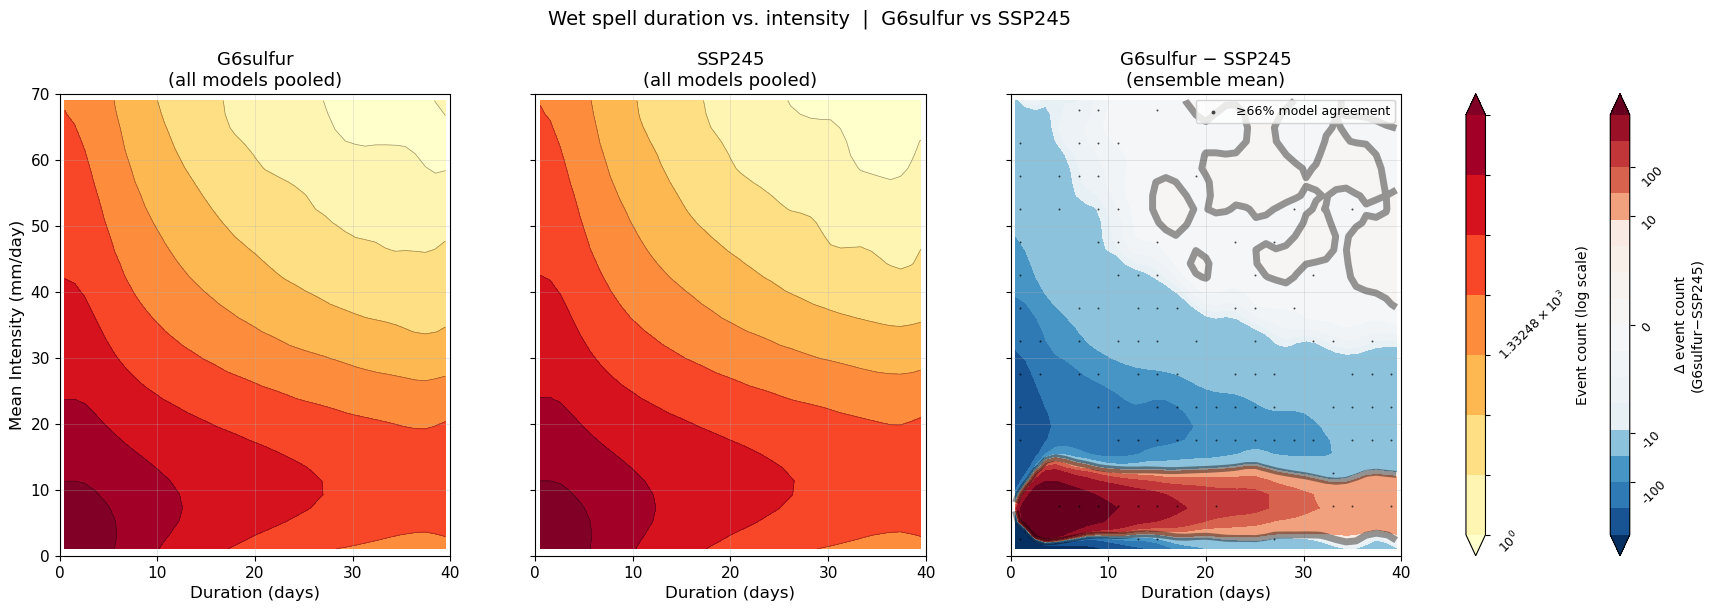

In [11]:
# Basic call
plot_wetspell_contours(counts_all, exp_a="G6sulfur", exp_b="SSP245")

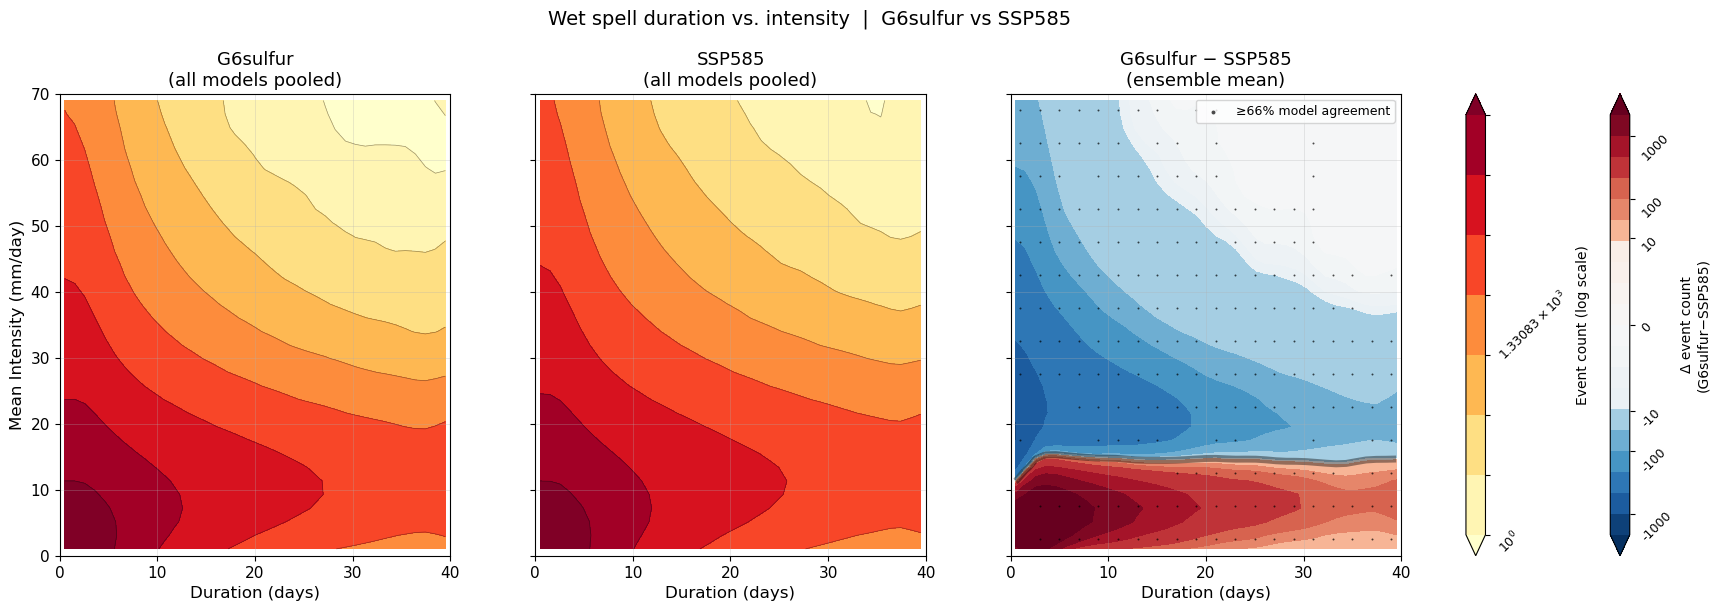

In [12]:
# Basic call
plot_wetspell_contours(counts_all, exp_a="G6sulfur", exp_b="SSP585")

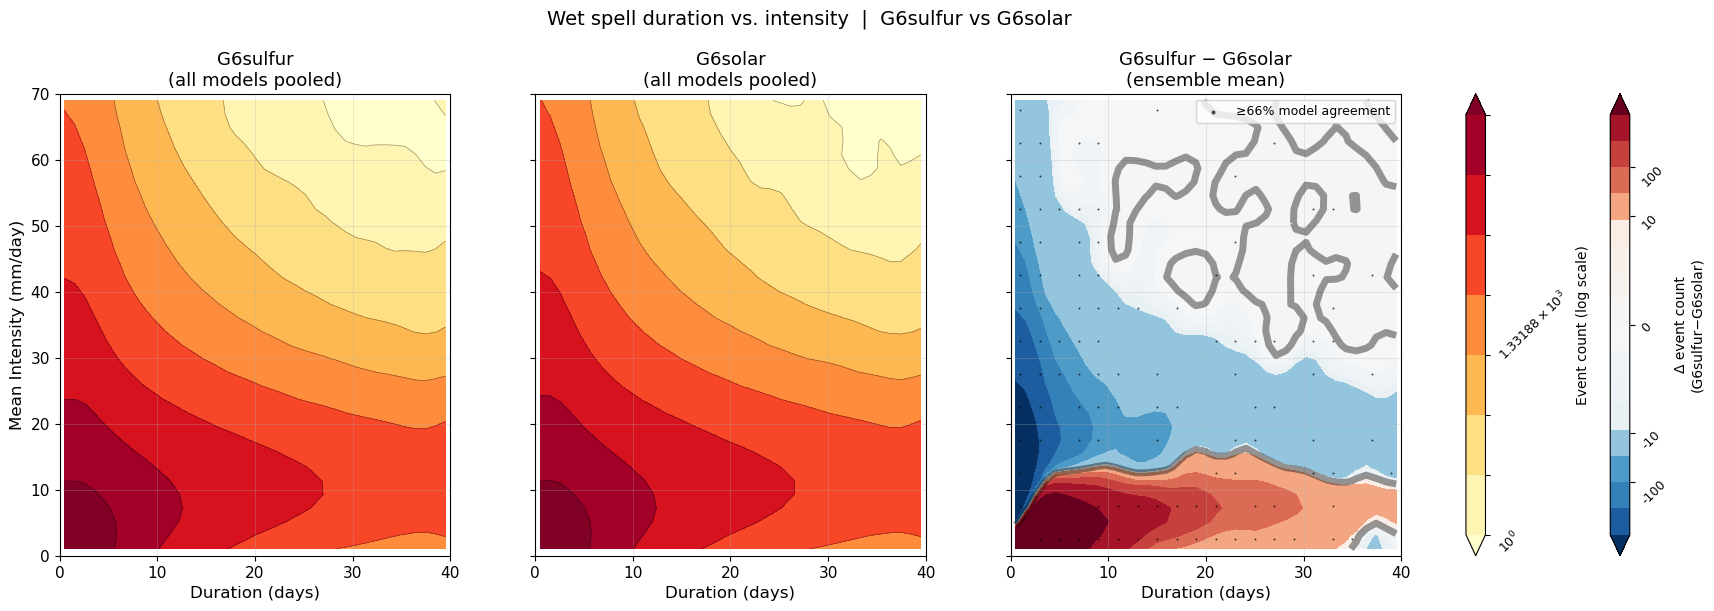

In [13]:
# Basic call
plot_wetspell_contours(counts_all, exp_a="G6sulfur", exp_b="G6solar")

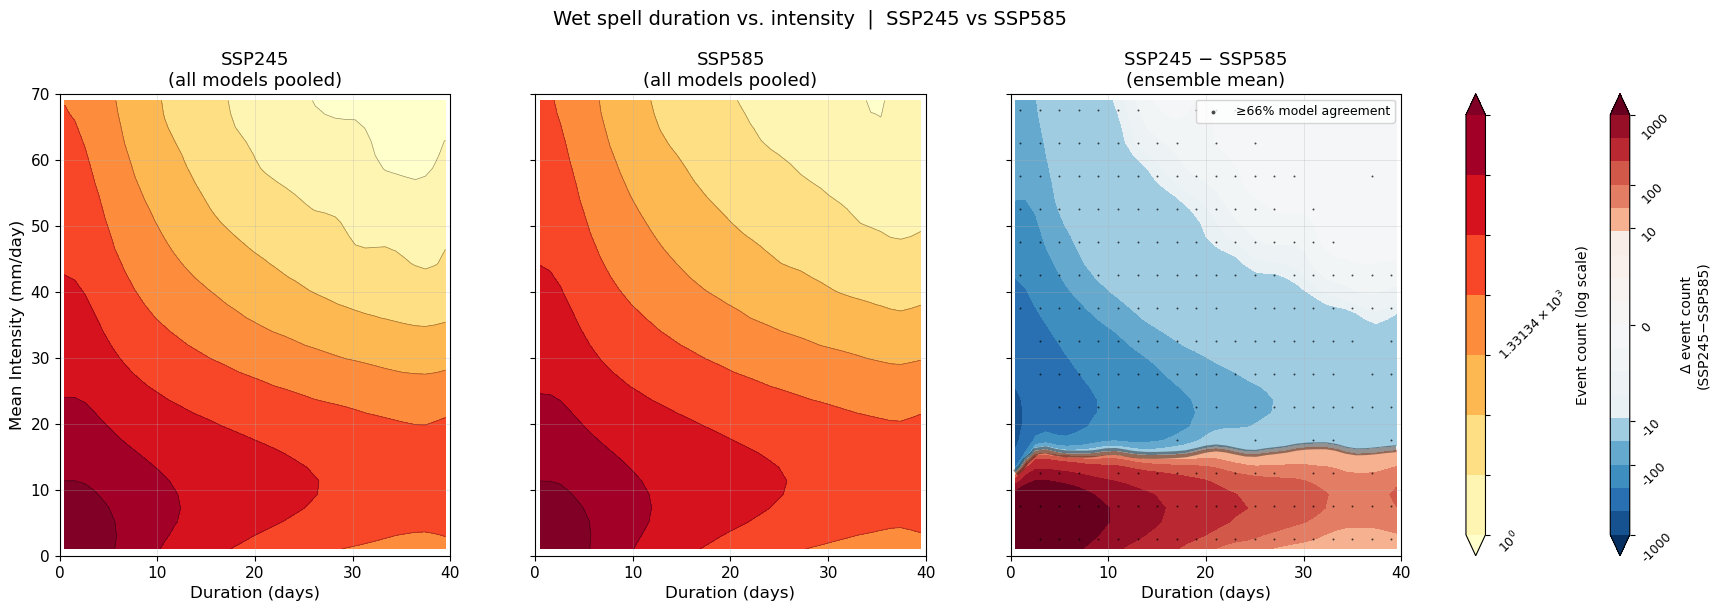

In [14]:
# Basic call
plot_wetspell_contours(counts_all, exp_a="SSP245", exp_b="SSP585")

# Events with details
## Events that are longer than 20days and stronger than mean intensity 20mm/day: location, date, total length, total rainfall

In [15]:
extreme_file = output_file.replace(".nc", "_extreme_events.csv")

In [16]:
# import os
# import pandas as pd

# # ── Criteria ──────────────────────────────────────────────────────────────────
# MIN_DURATION  = 20   # days
# MIN_INTENSITY = 20   # mm/day mean intensity

# if not os.path.exists(output_file):
#     print('#'*40)
#     print("File does not exist — running code")
#     print('#'*40)

#     counts_all   = {}
#     extreme_events = []   # list of dicts — one row per qualifying event

#     # =========================================================
#     # FUNCTION: GET EVENT PROPERTIES WITH LOCATION & DATE
#     # =========================================================

#     def get_event_properties_full(values_1d, dates_1d, lat, lon,
#                                    threshold=1,
#                                    min_duration=20, min_intensity=20):
#         """
#         Detect wet spell events and return basic stats for ALL events
#         plus detailed records (location, start date, length, total rain)
#         for events exceeding min_duration AND min_intensity.
#         """
#         wet = values_1d > threshold

#         durations     = []
#         intensities   = []
#         records       = []   # qualifying extreme events

#         current_vals  = []
#         current_dates = []

#         for val, date, is_wet in zip(values_1d, dates_1d, wet):
#             if is_wet:
#                 current_vals.append(val)
#                 current_dates.append(date)
#             else:
#                 if len(current_vals) > 0:
#                     dur        = len(current_vals)
#                     mean_int   = float(np.mean(current_vals))
#                     total_rain = float(np.sum(current_vals))

#                     durations.append(dur)
#                     intensities.append(mean_int)

#                     # ── Record if it meets the criteria ──
#                     if dur >= min_duration and mean_int >= min_intensity:
#                         records.append({
#                             "lat":        lat,
#                             "lon":        lon,
#                             "start_date": current_dates[0],
#                             "end_date":   current_dates[-1],
#                             "duration":   dur,
#                             "mean_intensity":  mean_int,
#                             "total_rainfall":  total_rain,
#                         })

#                     current_vals  = []
#                     current_dates = []

#         # Trailing event
#         if len(current_vals) > 0:
#             dur        = len(current_vals)
#             mean_int   = float(np.mean(current_vals))
#             total_rain = float(np.sum(current_vals))

#             durations.append(dur)
#             intensities.append(mean_int)

#             if dur >= min_duration and mean_int >= min_intensity:
#                 records.append({
#                     "lat":        lat,
#                     "lon":        lon,
#                     "start_date": current_vals[0] if current_dates else None,
#                     "end_date":   current_dates[-1] if current_dates else None,
#                     "duration":   dur,
#                     "mean_intensity": mean_int,
#                     "total_rainfall": total_rain,
#                 })

#         return np.array(durations), np.array(intensities), records

#     # =========================================================
#     # MAIN LOOP
#     # =========================================================

#     for model_name, model_meta in MODELS.items():
#         counts_all[model_name] = {}
#         for exp, meta in EXPERIMENTS.items():
#             if model_name == "CESM2-WACCM":
#                 ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
#             else:
#                 ensemble = model_meta["ensemble"]

#             base = (
#                 CEDA_BASE
#                 / meta["project"]
#                 / model_meta["institution"]
#                 / model_name
#                 / meta["scenario"]
#                 / ensemble
#                 / "day"
#                 / varname
#                 / model_meta["grid"]
#                 / "latest"
#             )

#             print(f"Reading {model_name} {exp}")
#             ds = mf.open_files(str(base))
#             da = mf.read_var(ds, varname)

#             # ---- Time selection ----
#             cal = da.time.dt.calendar
#             cftime_map = {
#                 "proleptic_gregorian": cftime.DatetimeProlepticGregorian,
#                 "gregorian":           cftime.DatetimeGregorian,
#                 "standard":            cftime.DatetimeGregorian,
#                 "365_day":             cftime.DatetimeNoLeap,
#                 "noleap":              cftime.DatetimeNoLeap,
#                 "360_day":             cftime.Datetime360Day,
#                 "all_leap":            cftime.DatetimeAllLeap,
#                 "366_day":             cftime.DatetimeAllLeap,
#             }
#             if model_name == "CESM2-WACCM":
#                 da = da.sel(time=slice(
#                     cftime.DatetimeNoLeap(2071, 1, 1),
#                     cftime.DatetimeNoLeap(2100, 12, 30)
#                 )).load()
#             else:
#                 dt_type = cftime_map.get(cal)
#                 da = da.sel(time=slice(
#                     dt_type(2071, 1, 1),
#                     dt_type(2100, 12, 31)
#                 )).load()

#             # ---- Tropics & unit conversion ----
#             da_tropics = da.sel(lat=slice(trop_lat_min, trop_lat_max))
#             da_mm      = da_tropics * 86400   # kg/m²/s → mm/day

#             # ---- Extract time axis as strings for portability ----
#             times = da_mm.time.values   # cftime or numpy datetime array

#             # ---- Loop over grid points ----
#             nlat = da_mm.sizes["lat"]
#             nlon = da_mm.sizes["lon"]

#             all_durations   = []
#             all_intensities = []
#             model_exp_records = []

#             lats = da_mm.lat.values
#             lons = da_mm.lon.values

#             for i in range(nlat):
#                 for j in range(nlon):
#                     ts = da_mm.isel(lat=i, lon=j).values
#                     finite_mask = np.isfinite(ts)
#                     ts_clean    = ts[finite_mask]
#                     t_clean     = times[finite_mask]

#                     if len(ts_clean) == 0:
#                         continue

#                     dur, inten, recs = get_event_properties_full(
#                         ts_clean, t_clean,
#                         lat=float(lats[i]),
#                         lon=float(lons[j]),
#                         threshold=1,
#                         min_duration=MIN_DURATION,
#                         min_intensity=MIN_INTENSITY,
#                     )
#                     all_durations.append(dur)
#                     all_intensities.append(inten)

#                     # Tag each record with model and experiment
#                     for r in recs:
#                         r["model"]      = model_name
#                         r["experiment"] = exp
#                     model_exp_records.extend(recs)

#             all_durations   = np.concatenate(all_durations)
#             all_intensities = np.concatenate(all_intensities)

#             counts_all[model_name][exp] = {
#                 "durations":   all_durations,
#                 "intensities": all_intensities,
#             }

#             extreme_events.extend(model_exp_records)

#             print(f"  → {len(all_durations)} total events, "
#                   f"{len(model_exp_records)} extreme events "
#                   f"(≥{MIN_DURATION}d, ≥{MIN_INTENSITY}mm/day)")

#     # ================================================================
#     # SAVE counts_all NetCDF (unchanged)
#     # ================================================================

#     print(f"\nSaving to {output_file}...")
#     data_vars = {}
#     for model_name, exps in counts_all.items():
#         for exp, data in exps.items():
#             safe_key = f"{model_name}__{exp}"
#             dim_name = f"events__{safe_key}"
#             data_vars[f"{safe_key}__durations"] = xr.Variable(
#                 dims=[dim_name],
#                 data=data["durations"].astype(np.int32),
#                 attrs={"units": "days", "model": model_name, "experiment": exp}
#             )
#             data_vars[f"{safe_key}__intensities"] = xr.Variable(
#                 dims=[dim_name],
#                 data=data["intensities"].astype(np.float32),
#                 attrs={"units": "mm/day", "model": model_name, "experiment": exp}
#             )
#     ds_out = xr.Dataset(data_vars)
#     ds_out.to_netcdf(output_file)
#     print(f"✓ Saved {output_file}")

#     # ================================================================
#     # SAVE extreme events CSV
#     # ================================================================

#     extreme_file = output_file.replace(".nc", "_extreme_events.csv")
#     df_extreme = pd.DataFrame(extreme_events)

#     # Convert cftime dates to strings for CSV portability
#     for col in ["start_date", "end_date"]:
#         if col in df_extreme.columns:
#             df_extreme[col] = df_extreme[col].astype(str)

#     df_extreme.to_csv(extreme_file, index=False)
#     print(f"✓ Saved extreme events → {extreme_file}")
#     print(f"  Total extreme events across all models/experiments: {len(df_extreme)}")
#     print(df_extreme.head())

# else:
#     print('#'*40)
#     print(f"{output_file} already exists — skipping its computation")
#     counts_all = load_counts_all(output_file)

#     # Load extreme events if they exist
#     extreme_file = output_file.replace(".nc", "_extreme_events.csv")
#     if os.path.exists(extreme_file):
#         df_extreme = pd.read_csv(extreme_file)
#         print(f"  Loaded {len(df_extreme)} extreme events from {extreme_file}")
#     print('#'*40)

In [17]:
import os
import pandas as pd

# ── Criteria ──────────────────────────────────────────────────────────────────
MIN_DURATION  = 20   # days
MIN_INTENSITY = 40   # mm/day

extreme_file = output_file.replace(".nc", "_extreme_events_above_40mm.csv")

if os.path.exists(extreme_file):
    print(f"Loading existing extreme events from {extreme_file}")
    df_extreme = pd.read_csv(extreme_file)
    print(f"  Loaded {len(df_extreme)} extreme events")

else:
    print(f"Computing extreme events (≥{MIN_DURATION}d, ≥{MIN_INTENSITY}mm/day)...")

    # ── Event detector ────────────────────────────────────────────────────────
    def find_extreme_events(values_1d, dates_1d, lat, lon,
                            threshold=1, min_duration=20, min_intensity=20):
        wet = values_1d > threshold
        records = []
        current_vals, current_dates = [], []

        for val, date, is_wet in zip(values_1d, dates_1d, wet):
            if is_wet:
                current_vals.append(val)
                current_dates.append(date)
            else:
                if len(current_vals) > 0:
                    dur      = len(current_vals)
                    mean_int = float(np.mean(current_vals))
                    if dur >= min_duration and mean_int >= min_intensity:
                        records.append({
                            "lat":            lat,
                            "lon":            lon,
                            "start_date":     str(current_dates[0]),
                            "end_date":       str(current_dates[-1]),
                            "duration":       dur,
                            "mean_intensity": mean_int,
                            "total_rainfall": float(np.sum(current_vals)),
                        })
                    current_vals, current_dates = [], []

        # trailing event
        if len(current_vals) > 0:
            dur      = len(current_vals)
            mean_int = float(np.mean(current_vals))
            if dur >= min_duration and mean_int >= min_intensity:
                records.append({
                    "lat":            lat,
                    "lon":            lon,
                    "start_date":     str(current_dates[0]) if current_dates else None,
                    "end_date":       str(current_dates[-1]) if current_dates else None,
                    "duration":       dur,
                    "mean_intensity": mean_int,
                    "total_rainfall": float(np.sum(current_vals)),
                })
        return records

    # ── Main loop ─────────────────────────────────────────────────────────────
    extreme_events = []

    cftime_map = {
        "proleptic_gregorian": cftime.DatetimeProlepticGregorian,
        "gregorian":           cftime.DatetimeGregorian,
        "standard":            cftime.DatetimeGregorian,
        "365_day":             cftime.DatetimeNoLeap,
        "noleap":              cftime.DatetimeNoLeap,
        "360_day":             cftime.Datetime360Day,
        "all_leap":            cftime.DatetimeAllLeap,
        "366_day":             cftime.DatetimeAllLeap,
    }

    for model_name, model_meta in MODELS.items():
        for exp, meta in EXPERIMENTS.items():
            print(f"  {model_name} {exp} ...", end=" ", flush=True)

            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
            else:
                ensemble = model_meta["ensemble"]

            base = (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "day"
                / varname
                / model_meta["grid"]
                / "latest"
            )

            ds = mf.open_files(str(base))
            da = mf.read_var(ds, varname)

            # ---- Time selection ----
            # ---- Time selection ----
            cal = da.time.dt.calendar
            if model_name == "CESM2-WACCM":
                da = da.sel(time=slice(
                    cftime.DatetimeNoLeap(2071, 1, 1),
                    cftime.DatetimeNoLeap(2100, 12, 30)
                )).load()
            else:
                dt_type = cftime_map.get(cal)
                if dt_type is None:
                    raise ValueError(f"Unknown calendar '{cal}' for {model_name}")

                # 360-day calendars have no 31st — use 30th as end date
                end_day = 30 if cal == "360_day" else 31

                da = da.sel(time=slice(
                    dt_type(2071, 1,  1),
                    dt_type(2100, 12, end_day)
                )).load()
            # ---- Tropics & unit conversion ----
            da_tropics = da.sel(lat=slice(trop_lat_min, trop_lat_max))
            da_mm      = da_tropics * 86400   # kg/m²/s → mm/day
            times      = da_mm.time.values
            lats       = da_mm.lat.values
            lons       = da_mm.lon.values

            n_found = 0
            for i in range(da_mm.sizes["lat"]):
                for j in range(da_mm.sizes["lon"]):
                    ts          = da_mm.isel(lat=i, lon=j).values
                    finite_mask = np.isfinite(ts)
                    ts_clean    = ts[finite_mask]
                    t_clean     = times[finite_mask]
                    if len(ts_clean) == 0:
                        continue

                    recs = find_extreme_events(
                        ts_clean, t_clean,
                        lat=float(lats[i]),
                        lon=float(lons[j]),
                        threshold=1,
                        min_duration=MIN_DURATION,
                        min_intensity=MIN_INTENSITY,
                    )
                    for r in recs:
                        r["model"]      = model_name
                        r["experiment"] = exp
                    extreme_events.extend(recs)
                    n_found += len(recs)

            print(f"{n_found} extreme events found")

    # ── Save ──────────────────────────────────────────────────────────────────
    df_extreme = pd.DataFrame(extreme_events, columns=[
        "model", "experiment", "lat", "lon",
        "start_date", "end_date",
        "duration", "mean_intensity", "total_rainfall"
    ])
    df_extreme.to_csv(extreme_file, index=False)
    print(f"\n✓ Saved → {extreme_file}")
    print(f"  Total extreme events: {len(df_extreme)}")
    print(df_extreme.head())

Loading existing extreme events from /gws/ssde/j25b/impose/bidyut/analysis_transient_data/length_strength_extreme_events_above_40mm.csv
  Loaded 13010 extreme events


In [18]:
import os
import pandas as pd

# ── Criteria ──────────────────────────────────────────────────────────────────
MIN_DURATION  = 1   # days
MIN_INTENSITY = 1   # mm/day

extreme_file = output_file.replace(".nc", "_rainy_events_above_1mm.csv")

if os.path.exists(extreme_file):
    print(f"Loading existing extreme events from {extreme_file}")
    df_extreme = pd.read_csv(extreme_file)
    print(f"  Loaded {len(df_extreme)} extreme events")

else:
    print(f"Computing extreme events (≥{MIN_DURATION}d, ≥{MIN_INTENSITY}mm/day)...")

    # ── Event detector ────────────────────────────────────────────────────────
    def find_rain_events(values_1d, dates_1d, lat, lon,
                            threshold=1, min_duration=20, min_intensity=20):
        wet = values_1d > threshold
        records = []
        current_vals, current_dates = [], []

        for val, date, is_wet in zip(values_1d, dates_1d, wet):
            if is_wet:
                current_vals.append(val)
                current_dates.append(date)
            else:
                if len(current_vals) > 0:
                    dur      = len(current_vals)
                    mean_int = float(np.mean(current_vals))
                    if dur >= min_duration and mean_int >= min_intensity:
                        records.append({
                            # "lat":            lat,
                            # "lon":            lon,
                            # "start_date":     str(current_dates[0]),
                            # "end_date":       str(current_dates[-1]),
                            "duration":       dur,
                            "mean_intensity": mean_int,
                            "total_rainfall": float(np.sum(current_vals)),
                        })
                    current_vals, current_dates = [], []

        # trailing event
        if len(current_vals) > 0:
            dur      = len(current_vals)
            mean_int = float(np.mean(current_vals))
            if dur >= min_duration and mean_int >= min_intensity:
                records.append({
                    # "lat":            lat,
                    # "lon":            lon,
                    # "start_date":     str(current_dates[0]) if current_dates else None,
                    # "end_date":       str(current_dates[-1]) if current_dates else None,
                    "duration":       dur,
                    "mean_intensity": mean_int,
                    "total_rainfall": float(np.sum(current_vals)),
                })
        return records

    # ── Main loop ─────────────────────────────────────────────────────────────
    extreme_events = []

    cftime_map = {
        "proleptic_gregorian": cftime.DatetimeProlepticGregorian,
        "gregorian":           cftime.DatetimeGregorian,
        "standard":            cftime.DatetimeGregorian,
        "365_day":             cftime.DatetimeNoLeap,
        "noleap":              cftime.DatetimeNoLeap,
        "360_day":             cftime.Datetime360Day,
        "all_leap":            cftime.DatetimeAllLeap,
        "366_day":             cftime.DatetimeAllLeap,
    }

    for model_name, model_meta in MODELS.items():
        for exp, meta in EXPERIMENTS.items():
            print(f"  {model_name} {exp} ...", end=" ", flush=True)

            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
            else:
                ensemble = model_meta["ensemble"]

            base = (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "day"
                / varname
                / model_meta["grid"]
                / "latest"
            )

            ds = mf.open_files(str(base))
            da = mf.read_var(ds, varname)

            # ---- Time selection ----
            # ---- Time selection ----
            cal = da.time.dt.calendar
            if model_name == "CESM2-WACCM":
                da = da.sel(time=slice(
                    cftime.DatetimeNoLeap(2071, 1, 1),
                    cftime.DatetimeNoLeap(2100, 12, 30)
                )).load()
            else:
                dt_type = cftime_map.get(cal)
                if dt_type is None:
                    raise ValueError(f"Unknown calendar '{cal}' for {model_name}")

                # 360-day calendars have no 31st — use 30th as end date
                end_day = 30 if cal == "360_day" else 31

                da = da.sel(time=slice(
                    dt_type(2071, 1,  1),
                    dt_type(2100, 12, end_day)
                )).load()
            # ---- Tropics & unit conversion ----
            da_tropics = da.sel(lat=slice(trop_lat_min, trop_lat_max))
            da_mm      = da_tropics * 86400   # kg/m²/s → mm/day
            times      = da_mm.time.values
            lats       = da_mm.lat.values
            lons       = da_mm.lon.values

            n_found = 0
            for i in range(da_mm.sizes["lat"]):
                for j in range(da_mm.sizes["lon"]):
                    ts          = da_mm.isel(lat=i, lon=j).values
                    finite_mask = np.isfinite(ts)
                    ts_clean    = ts[finite_mask]
                    t_clean     = times[finite_mask]
                    if len(ts_clean) == 0:
                        continue

                    recs = find_rain_events(
                        ts_clean, t_clean,
                        lat=float(lats[i]),
                        lon=float(lons[j]),
                        threshold=1,
                        min_duration=MIN_DURATION,
                        min_intensity=MIN_INTENSITY,
                    )
                    for r in recs:
                        r["model"]      = model_name
                        r["experiment"] = exp
                    extreme_events.extend(recs)
                    n_found += len(recs)

            print(f"{n_found} extreme events found")

    # ── Save ──────────────────────────────────────────────────────────────────
    df_extreme = pd.DataFrame(extreme_events, columns=[
        "model", "experiment", 
        # "lat", "lon",
        # "start_date", "end_date",
        "duration", "mean_intensity", "total_rainfall"
    ])
    df_extreme.to_csv(extreme_file, index=False)
    print(f"\n✓ Saved → {extreme_file}")
    print(f"  Total extreme events: {len(df_extreme)}")
    print(df_extreme.head())

Loading existing extreme events from /gws/ssde/j25b/impose/bidyut/analysis_transient_data/length_strength_rainy_events_above_1mm.csv
  Loaded 182915727 extreme events


# EXTRA

In [19]:
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import numpy as np
# from matplotlib.colors import Normalize
# from matplotlib.cm import ScalarMappable

# # =========================================================
# # CONFIG
# # =========================================================

# EXP_A      = "G6sulfur"
# EXP_B      = "SSP245"
# THRESHOLD  = 1          # mm/day (must match what was used in get_event_properties)
# AGREE_FRAC = 0.66       # fraction of models that must agree for stippling

# # Hexbin grid & shared color range
# GRIDSIZE   = 15
# DUR_MAX    = 40
# INT_MAX    = 70
# VMAX       = 35         # max count per hexbin cell (for actual panels)
# DIFF_VMAX  = 15         # symmetric range for difference panel

# # Bin edges for 2-D histogramming (used to compute per-model agreement)
# DUR_BINS   = np.arange(0, DUR_MAX + 1, 2)
# INT_BINS   = np.arange(0, INT_MAX + 1, 5)

# # =========================================================
# # HELPER: pool all models → one hexbin array
# # =========================================================

# def pool_experiment(counts_all, exp):
#     """Concatenate durations & intensities across all models for one experiment."""
#     all_dur, all_int = [], []
#     for model_name, exps in counts_all.items():
#         if exp in exps:
#             all_dur.append(exps[exp]["durations"])
#             all_int.append(exps[exp]["intensities"])
#     return np.concatenate(all_dur), np.concatenate(all_int)


# # =========================================================
# # HELPER: 2-D histogram per model (for stippling)
# # =========================================================

# def per_model_2d_hist(counts_all, exp, dur_bins, int_bins):
#     """
#     Returns array of shape (n_models, n_dur_bins, n_int_bins)
#     with counts per bin for each model.
#     """
#     hists = []
#     for model_name, exps in counts_all.items():
#         if exp not in exps:
#             continue
#         dur = exps[exp]["durations"]
#         inten = exps[exp]["intensities"]
#         h, _, _ = np.histogram2d(dur, inten, bins=[dur_bins, int_bins])
#         hists.append(h)
#     return np.array(hists)   # (n_models, n_dur_bins, n_int_bins)


# # =========================================================
# # COMPUTE MODEL AGREEMENT FOR STIPPLING
# # =========================================================

# def compute_stippling(counts_all, exp_a, exp_b, dur_bins, int_bins, agree_frac):
#     """
#     For each 2-D bin, test whether the sign of (EXP_A - EXP_B) agrees
#     across >= agree_frac of the models.  Returns a boolean mask (True = agree).
#     """
#     hists_a = per_model_2d_hist(counts_all, exp_a, dur_bins, int_bins)
#     hists_b = per_model_2d_hist(counts_all, exp_b, dur_bins, int_bins)
#     n_models = hists_a.shape[0]

#     diff      = hists_a - hists_b                       # (n_models, nd, ni)
#     pos_frac  = (diff > 0).sum(axis=0) / n_models       # fraction with positive diff
#     neg_frac  = (diff < 0).sum(axis=0) / n_models       # fraction with negative diff

#     agree_mask = (pos_frac >= agree_frac) | (neg_frac >= agree_frac)
#     return agree_mask                                    # (n_dur_bins, n_int_bins)


# # =========================================================
# # COMPUTE ENSEMBLE-MEAN 2-D HISTOGRAM (for difference panel)
# # =========================================================

# def ensemble_mean_hist(counts_all, exp, dur_bins, int_bins):
#     hists = per_model_2d_hist(counts_all, exp, dur_bins, int_bins)
#     return hists.mean(axis=0)    # (n_dur_bins, n_int_bins)


# # =========================================================
# # PLOT
# # =========================================================

# fig = plt.figure(figsize=(18, 6))
# gs  = gridspec.GridSpec(1, 4, figure=fig, width_ratios=[1, 1, 1, 0.06], wspace=0.08)

# axes   = [fig.add_subplot(gs[i]) for i in range(3)]
# cax_ab = fig.add_subplot(gs[3])      # colorbar for actual panels

# # ---------- Pool all models ----------
# dur_a, int_a = pool_experiment(counts_all, EXP_A)
# dur_b, int_b = pool_experiment(counts_all, EXP_B)

# # ---------- Panel 1: EXP_A ----------
# ax = axes[0]
# hb_a = ax.hexbin(dur_a, int_a, gridsize=GRIDSIZE, mincnt=1,
#                  vmin=0, vmax=VMAX, cmap="YlOrRd")
# ax.set_title(f"{EXP_A}\n(all models pooled)", fontsize=13)
# ax.set_xlabel("Duration (days)", fontsize=12)
# ax.set_ylabel("Mean Intensity (mm/day)", fontsize=12)
# ax.set_xlim(0, DUR_MAX);  ax.set_xticks(np.arange(0, DUR_MAX + 1, 10))
# ax.set_ylim(0, INT_MAX);  ax.set_yticks(np.arange(0, INT_MAX + 1, 10))
# ax.grid(True, lw=0.4, alpha=0.5)

# # ---------- Panel 2: EXP_B ----------
# ax = axes[1]
# hb_b = ax.hexbin(dur_b, int_b, gridsize=GRIDSIZE, mincnt=1,
#                  vmin=0, vmax=VMAX, cmap="YlOrRd")
# ax.set_title(f"{EXP_B}\n(all models pooled)", fontsize=13)
# ax.set_xlabel("Duration (days)", fontsize=12)
# ax.set_xlim(0, DUR_MAX);  ax.set_xticks(np.arange(0, DUR_MAX + 1, 10))
# ax.set_ylim(0, INT_MAX);  ax.set_yticks(np.arange(0, INT_MAX + 1, 10))
# ax.tick_params(labelleft=False)
# ax.grid(True, lw=0.4, alpha=0.5)

# # Shared colorbar for panels 1 & 2
# fig.colorbar(hb_b, cax=cax_ab, label="Event count (pooled)")

# # ---------- Difference panel: EXP_A − EXP_B ----------
# mean_a = ensemble_mean_hist(counts_all, EXP_A, DUR_BINS, INT_BINS)
# mean_b = ensemble_mean_hist(counts_all, EXP_B, DUR_BINS, INT_BINS)
# diff   = mean_a - mean_b

# # Add a separate axes for the difference panel and its own colorbar
# # Squeeze the gridspec a little to make room for two colorbars
# ax = axes[2]

# # Compute bin centres for pcolormesh
# dur_centres = 0.5 * (DUR_BINS[:-1] + DUR_BINS[1:])
# int_centres  = 0.5 * (INT_BINS[:-1] + INT_BINS[1:])
# Xd, Yd = np.meshgrid(dur_centres, int_centres, indexing="ij")

# norm_diff = Normalize(vmin=-DIFF_VMAX, vmax=DIFF_VMAX)
# pm = ax.pcolormesh(DUR_BINS, INT_BINS, diff.T,
#                    norm=norm_diff, cmap="RdBu_r",
#                    shading="flat")

# # ---------- Stippling: dots where models agree ----------
# agree_mask = compute_stippling(counts_all, EXP_A, EXP_B,
#                                DUR_BINS, INT_BINS, AGREE_FRAC)

# # Only stipple cells where the ensemble-mean difference is non-trivial
# # (avoids a forest of dots in empty regions)
# nonzero_mask = (np.abs(diff) > 0)
# stip_mask    = agree_mask & nonzero_mask

# stip_x = Xd[stip_mask]
# stip_y = Yd[stip_mask]
# ax.scatter(stip_x, stip_y, s=8, c="k", marker=".", linewidths=0,
#            alpha=0.6, zorder=5, label=f"≥{int(AGREE_FRAC*100)}% model agreement")

# ax.set_title(f"{EXP_A} − {EXP_B}\n(ensemble mean)", fontsize=13)
# ax.set_xlabel("Duration (days)", fontsize=12)
# ax.set_xlim(0, DUR_MAX);  ax.set_xticks(np.arange(0, DUR_MAX + 1, 10))
# ax.set_ylim(0, INT_MAX);  ax.set_yticks(np.arange(0, INT_MAX + 1, 10))
# ax.tick_params(labelleft=False)
# ax.grid(True, lw=0.4, alpha=0.5)
# ax.legend(loc="upper right", fontsize=9, markerscale=2)

# # Difference colorbar — placed to the right of panel 3
# cax_diff = ax.inset_axes([1.04, 0, 0.06, 1])
# fig.colorbar(ScalarMappable(norm=norm_diff, cmap="RdBu_r"),
#              cax=cax_diff, label=f"Δ event count ({EXP_A}−{EXP_B})")

# plt.suptitle("Wet spell duration vs. intensity  |  2071–2100", fontsize=14, y=1.02)
# # plt.savefig("wetspell_hexbin_comparison.png", dpi=150, bbox_inches="tight")
# plt.show()

In [20]:
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import numpy as np
# from matplotlib.colors import Normalize, LogNorm
# from matplotlib.cm import ScalarMappable

# # =========================================================
# # CONFIG
# # =========================================================

# EXP_A      = "G6sulfur"
# EXP_B      = "SSP245"
# AGREE_FRAC = 0.66

# GRIDSIZE   = 15
# DUR_MAX    = 40
# INT_MAX    = 70
# DIFF_VMAX  = 15         # symmetric range for difference panel

# DUR_BINS   = np.arange(0, DUR_MAX + 1, 2)
# INT_BINS   = np.arange(0, INT_MAX + 1, 5)

# # =========================================================
# # HELPERS (unchanged from before)
# # =========================================================

# def pool_experiment(counts_all, exp):
#     all_dur, all_int = [], []
#     for model_name, exps in counts_all.items():
#         if exp in exps:
#             all_dur.append(exps[exp]["durations"])
#             all_int.append(exps[exp]["intensities"])
#     return np.concatenate(all_dur), np.concatenate(all_int)


# def per_model_2d_hist(counts_all, exp, dur_bins, int_bins):
#     hists = []
#     for model_name, exps in counts_all.items():
#         if exp not in exps:
#             continue
#         h, _, _ = np.histogram2d(
#             exps[exp]["durations"],
#             exps[exp]["intensities"],
#             bins=[dur_bins, int_bins]
#         )
#         hists.append(h)
#     return np.array(hists)


# def ensemble_mean_hist(counts_all, exp, dur_bins, int_bins):
#     return per_model_2d_hist(counts_all, exp, dur_bins, int_bins).mean(axis=0)


# def compute_stippling(counts_all, exp_a, exp_b, dur_bins, int_bins, agree_frac):
#     hists_a = per_model_2d_hist(counts_all, exp_a, dur_bins, int_bins)
#     hists_b = per_model_2d_hist(counts_all, exp_b, dur_bins, int_bins)
#     n_models  = hists_a.shape[0]
#     diff      = hists_a - hists_b
#     pos_frac  = (diff > 0).sum(axis=0) / n_models
#     neg_frac  = (diff < 0).sum(axis=0) / n_models
#     return (pos_frac >= agree_frac) | (neg_frac >= agree_frac)


# # =========================================================
# # DATA
# # =========================================================

# dur_a, int_a = pool_experiment(counts_all, EXP_A)
# dur_b, int_b = pool_experiment(counts_all, EXP_B)

# mean_a = ensemble_mean_hist(counts_all, EXP_A, DUR_BINS, INT_BINS)
# mean_b = ensemble_mean_hist(counts_all, EXP_B, DUR_BINS, INT_BINS)
# diff   = mean_a - mean_b

# agree_mask = compute_stippling(counts_all, EXP_A, EXP_B,
#                                DUR_BINS, INT_BINS, AGREE_FRAC)
# nonzero_mask = np.abs(diff) > 0
# stip_mask    = agree_mask & nonzero_mask

# dur_centres = 0.5 * (DUR_BINS[:-1] + DUR_BINS[1:])
# int_centres  = 0.5 * (INT_BINS[:-1] + INT_BINS[1:])
# Xd, Yd = np.meshgrid(dur_centres, int_centres, indexing="ij")

# # =========================================================
# # FIX 1: auto-scale VMAX from actual pooled data
# # =========================================================

# # Compute hexbin counts without plotting to get the real max
# fig_tmp, ax_tmp = plt.subplots()
# hb_tmp = ax_tmp.hexbin(dur_a, int_a, gridsize=GRIDSIZE, mincnt=1)
# VMAX = np.percentile(hb_tmp.get_array(), 98)   # 98th percentile avoids extreme outliers
# plt.close(fig_tmp)

# print(f"Auto VMAX = {VMAX:.0f}")

# # =========================================================
# # FIX 2: proper layout — 5 columns: panel | panel | panel | cbar_ab | cbar_diff
# # =========================================================

# fig = plt.figure(figsize=(19, 6))
# gs  = gridspec.GridSpec(
#     1, 5,
#     figure=fig,
#     width_ratios=[1, 1, 1, 0.045, 0.045],
#     wspace=0.25
# )

# ax1      = fig.add_subplot(gs[0])
# ax2      = fig.add_subplot(gs[1], sharey=ax1)
# ax3      = fig.add_subplot(gs[2], sharey=ax1)
# cax_ab   = fig.add_subplot(gs[3])   # colorbar for panels 1 & 2
# cax_diff = fig.add_subplot(gs[4])   # colorbar for panel 3

# # =========================================================
# # PANEL 1 — EXP_A
# # =========================================================

# hb_a = ax1.hexbin(
#     dur_a, int_a,
#     gridsize=GRIDSIZE, mincnt=1,
#     norm=LogNorm(vmin=1, vmax=VMAX),
#     cmap="YlOrRd"
# )
# ax1.set_title(f"{EXP_A}\n(all models pooled)", fontsize=13)
# ax1.set_xlabel("Duration (days)", fontsize=12)
# ax1.set_ylabel("Mean Intensity (mm/day)", fontsize=12)
# ax1.set_xlim(0, DUR_MAX);  ax1.set_xticks(np.arange(0, DUR_MAX + 1, 10))
# ax1.set_ylim(0, INT_MAX);  ax1.set_yticks(np.arange(0, INT_MAX + 1, 10))
# ax1.grid(True, lw=0.4, alpha=0.5)

# # =========================================================
# # PANEL 2 — EXP_B
# # =========================================================

# hb_b = ax2.hexbin(
#     dur_b, int_b,
#     gridsize=GRIDSIZE, mincnt=1,
#     norm=LogNorm(vmin=1, vmax=VMAX),
#     cmap="YlOrRd"
# )
# ax2.set_title(f"{EXP_B}\n(all models pooled)", fontsize=13)
# ax2.set_xlabel("Duration (days)", fontsize=12)
# ax2.set_xlim(0, DUR_MAX);  ax2.set_xticks(np.arange(0, DUR_MAX + 1, 10))
# ax2.tick_params(labelleft=False)
# ax2.grid(True, lw=0.4, alpha=0.5)

# # Shared colorbar for panels 1 & 2
# cb_ab = fig.colorbar(hb_b, cax=cax_ab)
# cb_ab.set_label("Event count (log scale)", fontsize=10)

# # =========================================================
# # PANEL 3 — DIFFERENCE
# # =========================================================

# norm_diff = Normalize(vmin=-DIFF_VMAX, vmax=DIFF_VMAX)
# pm = ax3.pcolormesh(
#     DUR_BINS, INT_BINS, diff.T,
#     norm=norm_diff, cmap="RdBu_r", shading="flat"
# )

# # Stippling
# ax3.scatter(
#     Xd[stip_mask], Yd[stip_mask],
#     s=8, c="k", marker=".", linewidths=0,
#     alpha=0.6, zorder=5,
#     label=f"≥{int(AGREE_FRAC*100)}% model agreement"
# )

# ax3.set_title(f"{EXP_A} − {EXP_B}\n(ensemble mean)", fontsize=13)
# ax3.set_xlabel("Duration (days)", fontsize=12)
# ax3.set_xlim(0, DUR_MAX);  ax3.set_xticks(np.arange(0, DUR_MAX + 1, 10))
# ax3.tick_params(labelleft=False)
# ax3.grid(True, lw=0.4, alpha=0.5)
# ax3.legend(loc="upper right", fontsize=9, markerscale=2)

# # Dedicated colorbar for difference panel
# cb_diff = fig.colorbar(pm, cax=cax_diff)
# cb_diff.set_label(f"Δ event count\n({EXP_A}−{EXP_B})", fontsize=10)
# cb_diff.set_ticks(np.arange(-DIFF_VMAX, DIFF_VMAX + 1, 5))

# # =========================================================
# # FINALISE
# # =========================================================

# plt.suptitle(
#     "Wet spell duration vs. intensity  |  2071–2100",
#     fontsize=14, y=1.02
# )
# # plt.savefig("wetspell_hexbin_comparison.png", dpi=150, bbox_inches="tight")
# plt.show()

Auto VMAX = 1578743


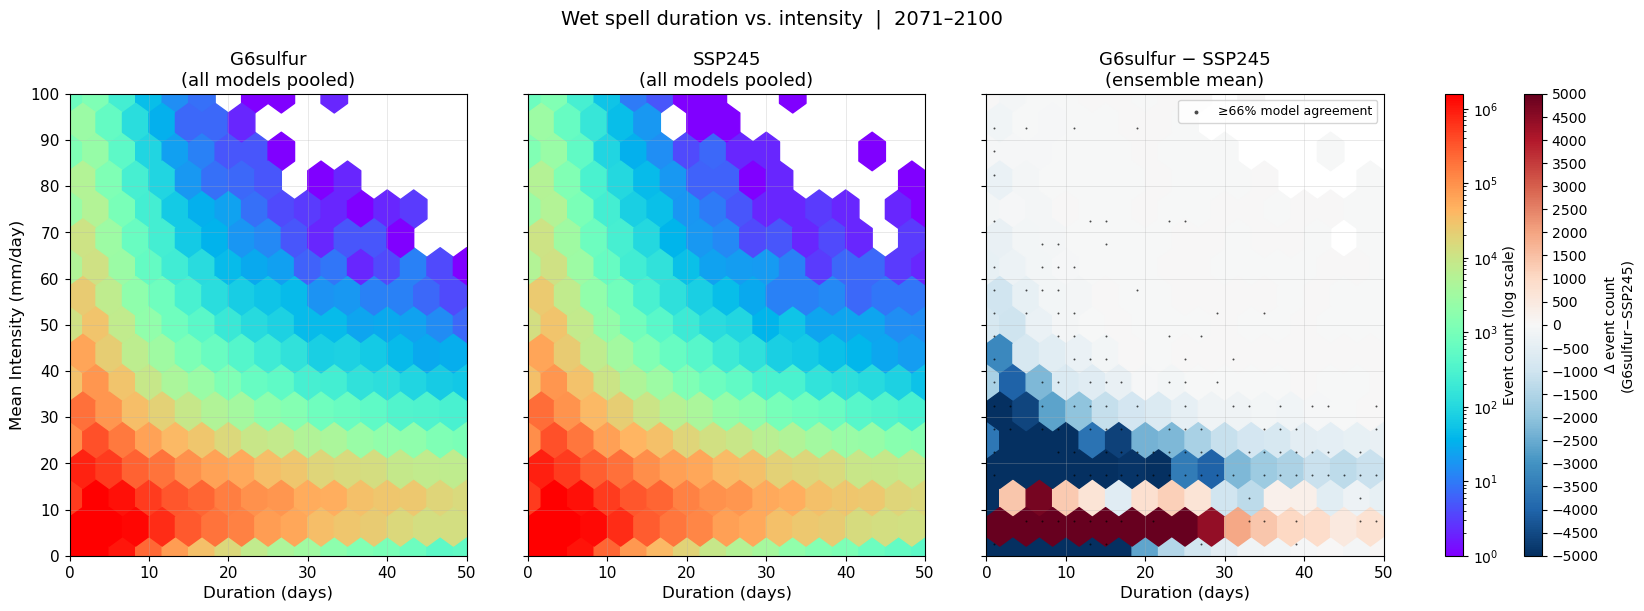

In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.colors import Normalize, LogNorm
from matplotlib.cm import ScalarMappable

# =========================================================
# CONFIG
# =========================================================

EXP_A      = "G6sulfur"
EXP_B      = "SSP245"
AGREE_FRAC = 0.66
GRIDSIZE   = 15
DUR_MAX    = 50
INT_MAX    = 100
DIFF_VMAX  = 5000   # adjust after first run if needed

DUR_BINS   = np.arange(0, DUR_MAX + 1, 2)
INT_BINS   = np.arange(0, INT_MAX + 1, 5)

# =========================================================
# HELPERS
# =========================================================

def pool_experiment(counts_all, exp):
    all_dur, all_int = [], []
    for model_name, exps in counts_all.items():
        if exp in exps:
            all_dur.append(exps[exp]["durations"])
            all_int.append(exps[exp]["intensities"])
    return np.concatenate(all_dur), np.concatenate(all_int)


def per_model_2d_hist(counts_all, exp, dur_bins, int_bins):
    hists = []
    for model_name, exps in counts_all.items():
        if exp not in exps:
            continue
        h, _, _ = np.histogram2d(
            exps[exp]["durations"],
            exps[exp]["intensities"],
            bins=[dur_bins, int_bins]
        )
        hists.append(h)
    return np.array(hists)   # (n_models, n_dur_bins, n_int_bins)


def compute_stippling(counts_all, exp_a, exp_b, dur_bins, int_bins, agree_frac):
    hists_a  = per_model_2d_hist(counts_all, exp_a, dur_bins, int_bins)
    hists_b  = per_model_2d_hist(counts_all, exp_b, dur_bins, int_bins)
    n_models = hists_a.shape[0]
    diff     = hists_a - hists_b
    pos_frac = (diff > 0).sum(axis=0) / n_models
    neg_frac = (diff < 0).sum(axis=0) / n_models
    return (pos_frac >= agree_frac) | (neg_frac >= agree_frac)


# =========================================================
# KEY HELPER: hexbin counts on a fixed extent
# Returns the PolyCollection AND the (n_hex,) count array
# so we can do arithmetic between two hexbins on the same grid
# =========================================================

def hexbin_fixed(ax, x, y, gridsize, extent, **kwargs):
    """
    Wrapper around ax.hexbin that forces a fixed extent so that
    the hex centres are identical across calls — essential for
    computing differences between two hexbin arrays.
    """
    hb = ax.hexbin(
        x, y,
        gridsize=gridsize,
        extent=extent,
        **kwargs          # mincnt comes entirely from the caller
    )
    return hb


# =========================================================
# DATA
# =========================================================

dur_a, int_a = pool_experiment(counts_all, EXP_A)
dur_b, int_b = pool_experiment(counts_all, EXP_B)

EXTENT = (0, DUR_MAX, 0, INT_MAX)

# =========================================================
# AUTO VMAX: get real count range from the data
# =========================================================

fig_tmp, ax_tmp = plt.subplots()
hb_tmp = hexbin_fixed(ax_tmp, dur_a, int_a, GRIDSIZE, EXTENT, mincnt=1)
counts_tmp = hb_tmp.get_array()
VMAX = np.percentile(counts_tmp[counts_tmp > 0], 98)
plt.close(fig_tmp)
print(f"Auto VMAX = {VMAX:.0f}")

# =========================================================
# FIGURE LAYOUT
# 5 columns: panel_A | panel_B | panel_diff | cbar_AB | cbar_diff
# =========================================================

fig = plt.figure(figsize=(19, 6))
gs  = gridspec.GridSpec(
    1, 5,
    figure=fig,
    width_ratios=[1, 1, 1, 0.045, 0.045],
    wspace=0.25
)

ax1      = fig.add_subplot(gs[0])
ax2      = fig.add_subplot(gs[1], sharey=ax1)
ax3      = fig.add_subplot(gs[2], sharey=ax1)
cax_ab   = fig.add_subplot(gs[3])
cax_diff = fig.add_subplot(gs[4])

# =========================================================
# PANEL 1 — EXP_A  (hexbin, log norm)
# =========================================================

hb_a = hexbin_fixed(
    ax1, dur_a, int_a,
    gridsize=GRIDSIZE,
    extent=EXTENT,
    norm=LogNorm(vmin=1, vmax=VMAX),
    cmap="rainbow",
    mincnt=1
)

ax1.set_title(f"{EXP_A}\n(all models pooled)", fontsize=13)
ax1.set_xlabel("Duration (days)", fontsize=12)
ax1.set_ylabel("Mean Intensity (mm/day)", fontsize=12)
ax1.set_xlim(0, DUR_MAX);  ax1.set_xticks(np.arange(0, DUR_MAX + 1, 10))
ax1.set_ylim(0, INT_MAX);  ax1.set_yticks(np.arange(0, INT_MAX + 1, 10))
ax1.tick_params(labelsize=11)
ax1.grid(True, lw=0.4, alpha=0.5)

# =========================================================
# PANEL 2 — EXP_B  (hexbin, log norm, same grid)
# =========================================================

hb_b = hexbin_fixed(
    ax2, dur_b, int_b,
    gridsize=GRIDSIZE,
    extent=EXTENT,
    norm=LogNorm(vmin=1, vmax=VMAX),
    cmap="rainbow",
    mincnt=1
)

ax2.set_title(f"{EXP_B}\n(all models pooled)", fontsize=13)
ax2.set_xlabel("Duration (days)", fontsize=12)
ax2.set_xlim(0, DUR_MAX);  ax2.set_xticks(np.arange(0, DUR_MAX + 1, 10))
ax2.tick_params(labelleft=False, labelsize=11)
ax2.grid(True, lw=0.4, alpha=0.5)

# Shared colorbar for panels 1 & 2
cb_ab = fig.colorbar(hb_b, cax=cax_ab)
cb_ab.set_label("Event count (log scale)", fontsize=10)

# # =========================================================
# # PANEL 3 — DIFFERENCE via hexbin arithmetic
# #
# # Strategy: draw two invisible hexbins on ax3 (mincnt=0 so
# # every hex cell is present), subtract their count arrays,
# # then create a NEW PolyCollection coloured by the diff.
# # =========================================================

# # Draw both hexbins on ax3 with mincnt=0 so arrays are aligned
# hb_d_a = hexbin_fixed(
#     ax3, dur_a, int_a,
#     gridsize=GRIDSIZE,
#     extent=EXTENT,
#     mincnt=0,
#     cmap="RdBu_r",
#     visible=False         # hide — we only want the geometry
# )
# hb_d_b = hexbin_fixed(
#     ax3, dur_b, int_b,
#     gridsize=GRIDSIZE,
#     extent=EXTENT,
#     mincnt=0,
#     cmap="RdBu_r",
#     visible=False
# )

# counts_diff = hb_d_a.get_array() - hb_d_b.get_array()

# # Clone geometry from hb_d_a and colour by difference
# from matplotlib.collections import PolyCollection
# import copy

# # Build a new PolyCollection with the same hex vertices
# verts = [path.vertices for path in hb_d_a.get_paths()]
# # get_paths() returns Path objects — convert to vertex arrays
# verts  = [path.vertices for path in hb_d_a.get_paths()]

# norm_diff = Normalize(vmin=-DIFF_VMAX, vmax=DIFF_VMAX)
# pc = PolyCollection(
#     verts,
#     array=counts_diff,
#     norm=norm_diff,
#     cmap="RdBu_r",
#     edgecolors="none",
#     transform=ax3.transData
# )

# # Only show cells where at least one experiment has events
# # (avoids colouring the whole empty space)
# mask_active = (hb_d_a.get_array() > 0) | (hb_d_b.get_array() > 0)
# pc.set_alpha(np.where(mask_active, 1.0, 0.0))

# ax3.add_collection(pc)


# =========================================================
# PANEL 3 — DIFFERENCE via hexbin arithmetic
# =========================================================

# Draw both hexbins on ax3 with mincnt=0 so arrays are aligned
hb_d_a = hexbin_fixed(
    ax3, dur_a, int_a,
    gridsize=GRIDSIZE,
    extent=EXTENT,
    mincnt=0,
    cmap="RdBu_r",
)
hb_d_b = hexbin_fixed(
    ax3, dur_b, int_b,
    gridsize=GRIDSIZE,
    extent=EXTENT,
    mincnt=0,
    cmap="RdBu_r",
)

counts_a_arr = hb_d_a.get_array().copy()
counts_b_arr = hb_d_b.get_array().copy()

counts_diff = counts_a_arr - counts_b_arr

# Mask cells where BOTH experiments have zero events → renders as transparent
active = (counts_a_arr > 0) | (counts_b_arr > 0)
counts_diff_masked = np.where(active, counts_diff, np.nan)

# Reuse hb_d_a geometry — just update its colours with the masked diff
norm_diff = Normalize(vmin=-DIFF_VMAX, vmax=DIFF_VMAX)
hb_d_a.set_array(counts_diff_masked)
hb_d_a.set_norm(norm_diff)
hb_d_a.set_cmap("RdBu_r")
hb_d_a.set_clim(-DIFF_VMAX, DIFF_VMAX)

# Hide the second hexbin — we don't need it rendered
hb_d_b.set_visible(False)

# ---- Stippling ----
agree_mask = compute_stippling(
    counts_all, EXP_A, EXP_B, DUR_BINS, INT_BINS, AGREE_FRAC
)

# Map stipple bin centres to hex space
dur_centres = 0.5 * (DUR_BINS[:-1] + DUR_BINS[1:])
int_centres  = 0.5 * (INT_BINS[:-1] + INT_BINS[1:])
Xd, Yd = np.meshgrid(dur_centres, int_centres, indexing="ij")

mean_a_h = per_model_2d_hist(counts_all, EXP_A, DUR_BINS, INT_BINS).mean(axis=0)
mean_b_h = per_model_2d_hist(counts_all, EXP_B, DUR_BINS, INT_BINS).mean(axis=0)
nonzero_mask = np.abs(mean_a_h - mean_b_h) > 0
stip_mask    = agree_mask & nonzero_mask

ax3.scatter(
    Xd[stip_mask], Yd[stip_mask],
    s=8, c="k", marker=".", linewidths=0,
    alpha=0.7, zorder=5,
    label=f"≥{int(AGREE_FRAC*100)}% model agreement"
)

ax3.set_title(f"{EXP_A} − {EXP_B}\n(ensemble mean)", fontsize=13)
ax3.set_xlabel("Duration (days)", fontsize=12)
ax3.set_xlim(0, DUR_MAX);  ax3.set_xticks(np.arange(0, DUR_MAX + 1, 10))
ax3.set_ylim(0, INT_MAX);  ax3.set_yticks(np.arange(0, INT_MAX + 1, 10))
ax3.tick_params(labelleft=False, labelsize=11)
ax3.grid(True, lw=0.4, alpha=0.5)
ax3.legend(loc="upper right", fontsize=9, markerscale=2)

# Difference colorbar
cb_diff = fig.colorbar(
    ScalarMappable(norm=norm_diff, cmap="RdBu_r"),
    cax=cax_diff
)
cb_diff.set_label(f"Δ event count\n({EXP_A}−{EXP_B})", fontsize=10)
cb_diff.set_ticks(np.arange(-DIFF_VMAX, DIFF_VMAX + 1, 500))

# =========================================================
# FINALISE
# =========================================================

plt.suptitle(
    "Wet spell duration vs. intensity  |  2071–2100",
    fontsize=14, y=1.02
)
# plt.savefig("wetspell_hexbin_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Auto VMAX = 1358400


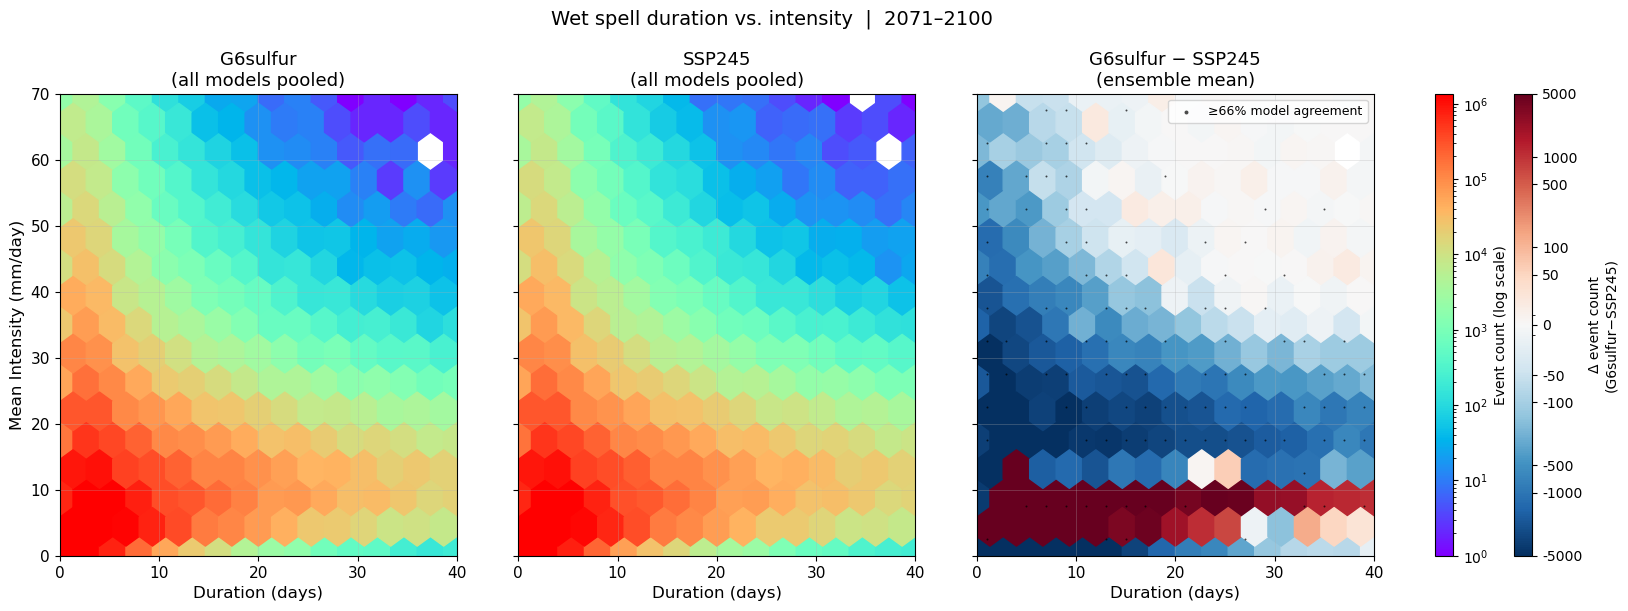

In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.colors import Normalize, LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import SymLogNorm

# =========================================================
# CONFIG
# =========================================================

EXP_A      = "G6sulfur"
EXP_B      = "SSP245"
AGREE_FRAC = 0.66
GRIDSIZE   = 15
DUR_MAX    = 40
INT_MAX    = 70
DIFF_VMAX  = 5000   # adjust after first run if needed

DUR_BINS   = np.arange(0, DUR_MAX + 1, 2)
INT_BINS   = np.arange(0, INT_MAX + 1, 5)

# =========================================================
# HELPERS
# =========================================================

def pool_experiment(counts_all, exp):
    all_dur, all_int = [], []
    for model_name, exps in counts_all.items():
        if exp in exps:
            all_dur.append(exps[exp]["durations"])
            all_int.append(exps[exp]["intensities"])
    return np.concatenate(all_dur), np.concatenate(all_int)


def per_model_2d_hist(counts_all, exp, dur_bins, int_bins):
    hists = []
    for model_name, exps in counts_all.items():
        if exp not in exps:
            continue
        h, _, _ = np.histogram2d(
            exps[exp]["durations"],
            exps[exp]["intensities"],
            bins=[dur_bins, int_bins]
        )
        hists.append(h)
    return np.array(hists)   # (n_models, n_dur_bins, n_int_bins)


def compute_stippling(counts_all, exp_a, exp_b, dur_bins, int_bins, agree_frac):
    hists_a  = per_model_2d_hist(counts_all, exp_a, dur_bins, int_bins)
    hists_b  = per_model_2d_hist(counts_all, exp_b, dur_bins, int_bins)
    n_models = hists_a.shape[0]
    diff     = hists_a - hists_b
    pos_frac = (diff > 0).sum(axis=0) / n_models
    neg_frac = (diff < 0).sum(axis=0) / n_models
    return (pos_frac >= agree_frac) | (neg_frac >= agree_frac)


# =========================================================
# KEY HELPER: hexbin counts on a fixed extent
# Returns the PolyCollection AND the (n_hex,) count array
# so we can do arithmetic between two hexbins on the same grid
# =========================================================

def hexbin_fixed(ax, x, y, gridsize, extent, **kwargs):
    """
    Wrapper around ax.hexbin that forces a fixed extent so that
    the hex centres are identical across calls — essential for
    computing differences between two hexbin arrays.
    """
    hb = ax.hexbin(
        x, y,
        gridsize=gridsize,
        extent=extent,
        **kwargs          # mincnt comes entirely from the caller
    )
    return hb


# =========================================================
# DATA
# =========================================================

dur_a, int_a = pool_experiment(counts_all, EXP_A)
dur_b, int_b = pool_experiment(counts_all, EXP_B)

EXTENT = (0, DUR_MAX, 0, INT_MAX)

# =========================================================
# AUTO VMAX: get real count range from the data
# =========================================================

fig_tmp, ax_tmp = plt.subplots()
hb_tmp = hexbin_fixed(ax_tmp, dur_a, int_a, GRIDSIZE, EXTENT, mincnt=1)
counts_tmp = hb_tmp.get_array()
VMAX = np.percentile(counts_tmp[counts_tmp > 0], 98)
plt.close(fig_tmp)
print(f"Auto VMAX = {VMAX:.0f}")

# =========================================================
# FIGURE LAYOUT
# 5 columns: panel_A | panel_B | panel_diff | cbar_AB | cbar_diff
# =========================================================

fig = plt.figure(figsize=(19, 6))
gs  = gridspec.GridSpec(
    1, 5,
    figure=fig,
    width_ratios=[1, 1, 1, 0.045, 0.045],
    wspace=0.25
)

ax1      = fig.add_subplot(gs[0])
ax2      = fig.add_subplot(gs[1], sharey=ax1)
ax3      = fig.add_subplot(gs[2], sharey=ax1)
cax_ab   = fig.add_subplot(gs[3])
cax_diff = fig.add_subplot(gs[4])

# =========================================================
# PANEL 1 — EXP_A  (hexbin, log norm)
# =========================================================

hb_a = hexbin_fixed(
    ax1, dur_a, int_a,
    gridsize=GRIDSIZE,
    extent=EXTENT,
    norm=LogNorm(vmin=1, vmax=VMAX),
    cmap="rainbow",
    mincnt=1
)

ax1.set_title(f"{EXP_A}\n(all models pooled)", fontsize=13)
ax1.set_xlabel("Duration (days)", fontsize=12)
ax1.set_ylabel("Mean Intensity (mm/day)", fontsize=12)
ax1.set_xlim(0, DUR_MAX);  ax1.set_xticks(np.arange(0, DUR_MAX + 1, 10))
ax1.set_ylim(0, INT_MAX);  ax1.set_yticks(np.arange(0, INT_MAX + 1, 10))
ax1.tick_params(labelsize=11)
ax1.grid(True, lw=0.4, alpha=0.5)

# =========================================================
# PANEL 2 — EXP_B  (hexbin, log norm, same grid)
# =========================================================

hb_b = hexbin_fixed(
    ax2, dur_b, int_b,
    gridsize=GRIDSIZE,
    extent=EXTENT,
    norm=LogNorm(vmin=1, vmax=VMAX),
    cmap="rainbow",
    mincnt=1
)

ax2.set_title(f"{EXP_B}\n(all models pooled)", fontsize=13)
ax2.set_xlabel("Duration (days)", fontsize=12)
ax2.set_xlim(0, DUR_MAX);  ax2.set_xticks(np.arange(0, DUR_MAX + 1, 10))
ax2.tick_params(labelleft=False, labelsize=11)
ax2.grid(True, lw=0.4, alpha=0.5)

# Shared colorbar for panels 1 & 2
cb_ab = fig.colorbar(hb_b, cax=cax_ab)
cb_ab.set_label("Event count (log scale)", fontsize=10)

# # =========================================================
# # PANEL 3 — DIFFERENCE via hexbin arithmetic
# #
# # Strategy: draw two invisible hexbins on ax3 (mincnt=0 so
# # every hex cell is present), subtract their count arrays,
# # then create a NEW PolyCollection coloured by the diff.
# # =========================================================

# # Draw both hexbins on ax3 with mincnt=0 so arrays are aligned
# hb_d_a = hexbin_fixed(
#     ax3, dur_a, int_a,
#     gridsize=GRIDSIZE,
#     extent=EXTENT,
#     mincnt=0,
#     cmap="RdBu_r",
#     visible=False         # hide — we only want the geometry
# )
# hb_d_b = hexbin_fixed(
#     ax3, dur_b, int_b,
#     gridsize=GRIDSIZE,
#     extent=EXTENT,
#     mincnt=0,
#     cmap="RdBu_r",
#     visible=False
# )

# counts_diff = hb_d_a.get_array() - hb_d_b.get_array()

# # Clone geometry from hb_d_a and colour by difference
# from matplotlib.collections import PolyCollection
# import copy

# # Build a new PolyCollection with the same hex vertices
# verts = [path.vertices for path in hb_d_a.get_paths()]
# # get_paths() returns Path objects — convert to vertex arrays
# verts  = [path.vertices for path in hb_d_a.get_paths()]

# norm_diff = Normalize(vmin=-DIFF_VMAX, vmax=DIFF_VMAX)
# pc = PolyCollection(
#     verts,
#     array=counts_diff,
#     norm=norm_diff,
#     cmap="RdBu_r",
#     edgecolors="none",
#     transform=ax3.transData
# )

# # Only show cells where at least one experiment has events
# # (avoids colouring the whole empty space)
# mask_active = (hb_d_a.get_array() > 0) | (hb_d_b.get_array() > 0)
# pc.set_alpha(np.where(mask_active, 1.0, 0.0))

# ax3.add_collection(pc)


# =========================================================
# PANEL 3 — DIFFERENCE via hexbin arithmetic
# =========================================================

# Draw both hexbins on ax3 with mincnt=0 so arrays are aligned
hb_d_a = hexbin_fixed(
    ax3, dur_a, int_a,
    gridsize=GRIDSIZE,
    extent=EXTENT,
    mincnt=0,
    cmap="RdBu_r",
)
hb_d_b = hexbin_fixed(
    ax3, dur_b, int_b,
    gridsize=GRIDSIZE,
    extent=EXTENT,
    mincnt=0,
    cmap="RdBu_r",
)

counts_a_arr = hb_d_a.get_array().copy()
counts_b_arr = hb_d_b.get_array().copy()

counts_diff = counts_a_arr - counts_b_arr

# Mask cells where BOTH experiments have zero events → renders as transparent
active = (counts_a_arr > 0) | (counts_b_arr > 0)
counts_diff_masked = np.where(active, counts_diff, np.nan)

# Reuse hb_d_a geometry — just update its colours with the masked diff
LINTHRESH = 50    # counts within ±50 shown on linear scale; beyond that → log

norm_diff = SymLogNorm(
    linthresh=LINTHRESH,
    linscale=0.5,        # how much space the linear region takes in the colorbar
    vmin=-DIFF_VMAX,
    vmax=DIFF_VMAX,
    base=10
)


# Then update the hexbin and colorbar as before:
hb_d_a.set_array(counts_diff_masked)
hb_d_a.set_norm(norm_diff)
hb_d_a.set_cmap("RdBu_r")

# Hide the second hexbin — we don't need it rendered
hb_d_b.set_visible(False)

# ---- Stippling ----
agree_mask = compute_stippling(
    counts_all, EXP_A, EXP_B, DUR_BINS, INT_BINS, AGREE_FRAC
)

# Map stipple bin centres to hex space
dur_centres = 0.5 * (DUR_BINS[:-1] + DUR_BINS[1:])
int_centres  = 0.5 * (INT_BINS[:-1] + INT_BINS[1:])
Xd, Yd = np.meshgrid(dur_centres, int_centres, indexing="ij")

mean_a_h = per_model_2d_hist(counts_all, EXP_A, DUR_BINS, INT_BINS).mean(axis=0)
mean_b_h = per_model_2d_hist(counts_all, EXP_B, DUR_BINS, INT_BINS).mean(axis=0)
nonzero_mask = np.abs(mean_a_h - mean_b_h) > 0
stip_mask    = agree_mask & nonzero_mask

ax3.scatter(
    Xd[stip_mask], Yd[stip_mask],
    s=8, c="k", marker=".", linewidths=0,
    alpha=0.7, zorder=5,
    label=f"≥{int(AGREE_FRAC*100)}% model agreement"
)

ax3.set_title(f"{EXP_A} − {EXP_B}\n(ensemble mean)", fontsize=13)
ax3.set_xlabel("Duration (days)", fontsize=12)
ax3.set_xlim(0, DUR_MAX);  ax3.set_xticks(np.arange(0, DUR_MAX + 1, 10))
ax3.set_ylim(0, INT_MAX);  ax3.set_yticks(np.arange(0, INT_MAX + 1, 10))
ax3.tick_params(labelleft=False, labelsize=11)
ax3.grid(True, lw=0.4, alpha=0.5)
ax3.legend(loc="upper right", fontsize=9, markerscale=2)

# Colorbar ticks — symmetric log spacing
cb_diff = fig.colorbar(
    ScalarMappable(norm=norm_diff, cmap="RdBu_r"),
    cax=cax_diff
)
cb_diff.set_label(f"Δ event count\n({EXP_A}−{EXP_B})", fontsize=10)

# Manually set symmetric log ticks
tick_vals = (
    [-DIFF_VMAX, -1000, -500, -100, -LINTHRESH, 0, LINTHRESH, 100, 500, 1000, DIFF_VMAX]
)
cb_diff.set_ticks(tick_vals)
cb_diff.set_ticklabels([str(v) for v in tick_vals])

# =========================================================
# FINALISE
# =========================================================

plt.suptitle(
    "Wet spell duration vs. intensity  |  2071–2100",
    fontsize=14, y=1.02
)
# plt.savefig("wetspell_hexbin_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

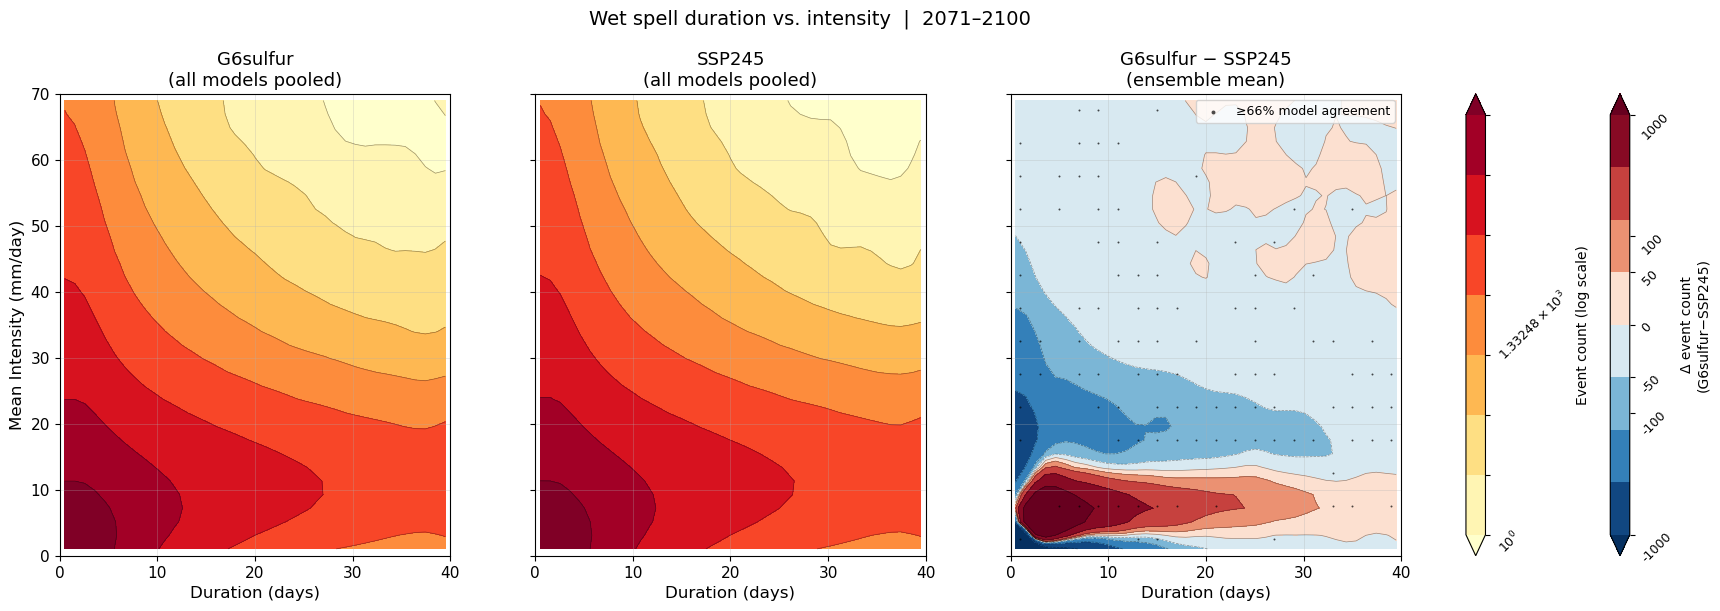

In [23]:
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter

# =========================================================
# CONFIG (add these)
# =========================================================
SMOOTH_SIGMA = 1.2    # gaussian smoothing for contour plots; increase to smooth more
N_LEVELS     = 8      # number of contour levels

# =========================================================
# HELPER: compute smoothed 2D density on a regular grid
# =========================================================

def compute_density(dur, inten, dur_bins, int_bins, sigma=1.2):
    """
    Bin events into a 2D histogram then apply Gaussian smoothing.
    Returns the smoothed array and the bin centre grids.
    """
    h, _, _ = np.histogram2d(dur, inten, bins=[dur_bins, int_bins])
    h_smooth = gaussian_filter(h, sigma=sigma)
    xc = 0.5 * (dur_bins[:-1] + dur_bins[1:])
    yc = 0.5 * (int_bins[:-1] + int_bins[1:])
    X, Y = np.meshgrid(xc, yc, indexing="ij")
    return X, Y, h_smooth


def compute_density_pooled(counts_all, exp, dur_bins, int_bins, sigma=1.2):
    """Pool all models then compute smoothed density."""
    dur, inten = pool_experiment(counts_all, exp)
    return compute_density(dur, inten, dur_bins, int_bins, sigma)


def compute_density_ensemble_mean(counts_all, exp, dur_bins, int_bins, sigma=1.2):
    """Average per-model histograms, then smooth."""
    hists = per_model_2d_hist(counts_all, exp, dur_bins, int_bins)
    h_mean = hists.mean(axis=0)
    h_smooth = gaussian_filter(h_mean, sigma=sigma)
    xc = 0.5 * (dur_bins[:-1] + dur_bins[1:])
    yc = 0.5 * (int_bins[:-1] + int_bins[1:])
    X, Y = np.meshgrid(xc, yc, indexing="ij")
    return X, Y, h_smooth


# =========================================================
# DATA
# =========================================================

DUR_BINS_C = np.linspace(0, DUR_MAX, 40)   # finer bins for smooth contours
INT_BINS_C = np.linspace(0, INT_MAX, 35)

Xa, Ya, Ha = compute_density_pooled(counts_all, EXP_A, DUR_BINS_C, INT_BINS_C, SMOOTH_SIGMA)
Xb, Yb, Hb = compute_density_pooled(counts_all, EXP_B, DUR_BINS_C, INT_BINS_C, SMOOTH_SIGMA)

# Difference uses ensemble mean per-model histograms
Xd, Yd, Ha_m = compute_density_ensemble_mean(counts_all, EXP_A, DUR_BINS_C, INT_BINS_C, SMOOTH_SIGMA)
_,  _,  Hb_m = compute_density_ensemble_mean(counts_all, EXP_B, DUR_BINS_C, INT_BINS_C, SMOOTH_SIGMA)
H_diff = Ha_m - Hb_m

# Common levels for panels 1 & 2 (log-spaced to match the dynamic range)
vmax_ab  = np.percentile([Ha, Hb], 98)
levels_ab = np.logspace(np.log10(max(1, Ha[Ha>0].min())),
                         np.log10(vmax_ab), N_LEVELS)

# Difference levels — symmetric log-spaced
diff_abs_max = np.nanpercentile(np.abs(H_diff), 98)
levels_pos   = np.logspace(np.log10(max(0.1, LINTHRESH)),
                            np.log10(diff_abs_max), N_LEVELS // 2)
levels_diff  = np.concatenate([-levels_pos[::-1], [0], levels_pos])

# Stippling (reuse existing DUR_BINS / INT_BINS from before)
agree_mask   = compute_stippling(counts_all, EXP_A, EXP_B, DUR_BINS, INT_BINS, AGREE_FRAC)
mean_a_h     = per_model_2d_hist(counts_all, EXP_A, DUR_BINS, INT_BINS).mean(axis=0)
mean_b_h     = per_model_2d_hist(counts_all, EXP_B, DUR_BINS, INT_BINS).mean(axis=0)
nonzero_mask = np.abs(mean_a_h - mean_b_h) > 0
stip_mask    = agree_mask & nonzero_mask
dur_sc = 0.5 * (DUR_BINS[:-1] + DUR_BINS[1:])
int_sc = 0.5 * (INT_BINS[:-1] + INT_BINS[1:])
Xs, Ys = np.meshgrid(dur_sc, int_sc, indexing="ij")

# =========================================================
# FIGURE LAYOUT
# =========================================================

fig = plt.figure(figsize=(20, 6))
gs  = gridspec.GridSpec(
    1, 5,
    figure=fig,
    width_ratios=[1, 1, 1, 0.05, 0.05],
    wspace=0.35          # ← increase this if still overlapping
)

ax1      = fig.add_subplot(gs[0])
ax2      = fig.add_subplot(gs[1], sharey=ax1)
ax3      = fig.add_subplot(gs[2], sharey=ax1)
cax_ab   = fig.add_subplot(gs[3])
cax_diff = fig.add_subplot(gs[4])

# =========================================================
# PANEL 1 — EXP_A
# =========================================================

cf1 = ax1.contourf(Xa, Ya, Ha, levels=levels_ab, extend="both",
                   cmap="YlOrRd", norm=LogNorm())
ax1.contour(Xa, Ya, Ha, levels=levels_ab,
            colors="k", linewidths=0.5, alpha=0.4)

ax1.set_title(f"{EXP_A}\n(all models pooled)", fontsize=13)
ax1.set_xlabel("Duration (days)", fontsize=12)
ax1.set_ylabel("Mean Intensity (mm/day)", fontsize=12)
ax1.set_xlim(0, DUR_MAX);  ax1.set_xticks(np.arange(0, DUR_MAX + 1, 10))
ax1.set_ylim(0, INT_MAX);  ax1.set_yticks(np.arange(0, INT_MAX + 1, 10))
ax1.tick_params(labelsize=11)
ax1.grid(True, lw=0.4, alpha=0.5)

# =========================================================
# PANEL 2 — EXP_B
# =========================================================

cf2 = ax2.contourf(Xb, Yb, Hb, levels=levels_ab, extend="both",
                   cmap="YlOrRd", norm=LogNorm())
ax2.contour(Xb, Yb, Hb, levels=levels_ab,
            colors="k", linewidths=0.5, alpha=0.4)

ax2.set_title(f"{EXP_B}\n(all models pooled)", fontsize=13)
ax2.set_xlabel("Duration (days)", fontsize=12)
ax2.set_xlim(0, DUR_MAX);  ax2.set_xticks(np.arange(0, DUR_MAX + 1, 10))
ax2.tick_params(labelleft=False, labelsize=11)
ax2.grid(True, lw=0.4, alpha=0.5)

# Shared colorbar for panels 1 & 2
cb_ab = fig.colorbar(cf2, cax=cax_ab)
cb_ab.set_label("Event count (log scale)", fontsize=10)
cb_ab.ax.tick_params(labelsize=9, rotation=45)   

# =========================================================
# PANEL 3 — DIFFERENCE (contourf with SymLogNorm)
# =========================================================

norm_diff = SymLogNorm(linthresh=LINTHRESH, linscale=0.5,
                       vmin=-diff_abs_max, vmax=diff_abs_max, base=10)

cf3 = ax3.contourf(Xd, Yd, H_diff, levels=levels_diff,
                   cmap="RdBu_r", norm=norm_diff, extend="both")
ax3.contour(Xd, Yd, H_diff, levels=levels_diff,
            colors="k", linewidths=0.5, alpha=0.4)

# Stippling
ax3.scatter(Xs[stip_mask], Ys[stip_mask],
            s=8, c="k", marker=".", linewidths=0,
            alpha=0.7, zorder=5,
            label=f"≥{int(AGREE_FRAC*100)}% model agreement")

ax3.set_title(f"{EXP_A} − {EXP_B}\n(ensemble mean)", fontsize=13)
ax3.set_xlabel("Duration (days)", fontsize=12)
ax3.set_xlim(0, DUR_MAX);  ax3.set_xticks(np.arange(0, DUR_MAX + 1, 10))
ax3.tick_params(labelleft=False, labelsize=11)
ax3.grid(True, lw=0.4, alpha=0.5)
ax3.legend(loc="upper right", fontsize=9, markerscale=2)

# Difference colorbar
cb_diff = fig.colorbar(cf3, cax=cax_diff, extend="both")
cb_diff.set_label(f"Δ event count\n({EXP_A}−{EXP_B})", fontsize=10)
# tick_vals = [-diff_abs_max, -1000, -100, -LINTHRESH,
#               0, LINTHRESH, 100, 1000, diff_abs_max]
tick_vals = [-1000, -100, -LINTHRESH,
              0, LINTHRESH, 100, 1000]
cb_diff.set_ticks(tick_vals)
cb_diff.set_ticklabels([f"{v:.0f}" for v in tick_vals])
cb_diff.ax.tick_params(labelsize=9, rotation=45)  

# =========================================================
# FINALISE
# =========================================================

plt.suptitle("Wet spell duration vs. intensity  |  2071–2100",
             fontsize=14, y=1.02)

# Fine-tune colorbar positions after tight_layout
plt.tight_layout()
pos_ab   = cax_ab.get_position()
pos_diff = cax_diff.get_position()
cax_ab.set_position([pos_ab.x0 - 0.01, pos_ab.y0,
                     pos_ab.width,      pos_ab.height])
cax_diff.set_position([pos_diff.x0 + 0.01, pos_diff.y0,
                       pos_diff.width,      pos_diff.height])

# plt.savefig("wetspell_contour_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Reading Length and Strength files

In [24]:
import pandas as pd

# ── Load extreme event CSVs ───────────────────────────────────────────────────

df_20mm = pd.read_csv("/gws/ssde/j25b/impose/bidyut/analysis_transient_data/length_strength_extreme_events.csv")
df_40mm = pd.read_csv("/gws/ssde/j25b/impose/bidyut/analysis_transient_data/length_strength_extreme_events_above_40mm.csv")

# Quick summary
for label, df in [("≥20mm/day", df_20mm), ("≥40mm/day", df_40mm)]:
    print(f"\n{label}  —  {len(df):,} events")
    print(f"  Models:      {sorted(df['model'].unique())}")
    print(f"  Experiments: {sorted(df['experiment'].unique())}")
    print(f"  Duration:    {df['duration'].min()}–{df['duration'].max()} days")
    print(f"  Intensity:   {df['mean_intensity'].min():.1f}–{df['mean_intensity'].max():.1f} mm/day")
    print(f"  Total rain:  {df['total_rainfall'].min():.1f}–{df['total_rainfall'].max():.1f} mm")
    print(df.head(3))


≥20mm/day  —  514,956 events
  Models:      ['CESM2-WACCM', 'CNRM-ESM2-1', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'UKESM1-0-LL']
  Experiments: ['G6solar', 'G6sulfur', 'SSP245', 'SSP585']
  Duration:    20–10956 days
  Intensity:   20.0–725.7 mm/day
  Total rain:  400.0–1054377.5 mm
         model experiment     lat       lon           start_date  \
0  UKESM1-0-LL     SSP245 -29.375  154.6875  2092-02-30 12:00:00   
1  UKESM1-0-LL     SSP245 -28.125  188.4375  2098-03-11 12:00:00   
2  UKESM1-0-LL     SSP245 -26.875   51.5625  2091-03-24 12:00:00   

              end_date  duration  mean_intensity  total_rainfall  
0  2092-03-20 12:00:00        21       21.924875      460.422363  
1  2098-04-07 12:00:00        27       22.035192      594.950195  
2  2091-04-14 12:00:00        21       25.556644      536.689514  

≥40mm/day  —  13,010 events
  Models:      ['CESM2-WACCM', 'CNRM-ESM2-1', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'UKESM1-0-LL']
  Experiments: ['G6solar', 'G6sulfur', 'SSP245', 'SSP585'

In [25]:
# Events in df_20mm that are also ≥40mm/day (should match df_40mm)
df_check = df_20mm[df_20mm["mean_intensity"] >= 40]

In [26]:
df_check

,model,experiment,lat,lon,start_date,end_date,duration,mean_intensity,total_rainfall
74,UKESM1-0-LL,SSP245,-21.87500,152.8125,2083-12-19 12:00:00,2084-01-12 12:00:00,24,56.237637,1349.703247
163,UKESM1-0-LL,SSP245,-20.62500,210.9375,2092-04-11 12:00:00,2092-05-01 12:00:00,21,44.556267,935.681580
221,UKESM1-0-LL,SSP245,-19.37500,42.1875,2094-02-12 12:00:00,2094-03-01 12:00:00,20,42.443687,848.873718
254,UKESM1-0-LL,SSP245,-19.37500,132.1875,2098-01-05 12:00:00,2098-01-25 12:00:00,21,45.766182,961.089844
373,UKESM1-0-LL,SSP245,-18.12500,36.5625,2079-01-12 12:00:00,2079-02-09 12:00:00,28,64.311012,1800.708374
...,...,...,...,...,...,...,...,...,...
514914,IPSL-CM6A-LR,G6sulfur,29.15493,95.0000,2078-05-24 12:00:00,2078-06-27 12:00:00,35,42.694927,1494.322510
514917,IPSL-CM6A-LR,G6sulfur,29.15493,95.0000,2083-09-19 12:00:00,2083-10-13 12:00:00,25,50.543022,1263.575562
514935,IPSL-CM6A-LR,G6sulfur,29.15493,95.0000,2094-01-31 12:00:00,2094-02-26 12:00:00,27,44.788086,1209.278320
514937,IPSL-CM6A-LR,G6sulfur,29.15493,95.0000,2095-06-29 12:00:00,2095-07-26 12:00:00,28,42.963428,1202.975952


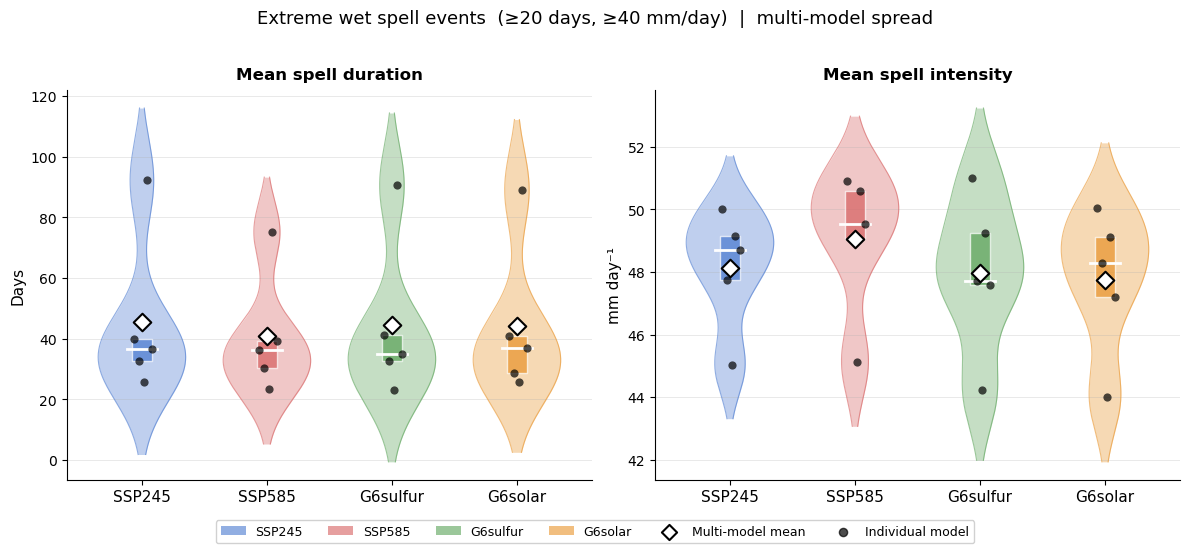

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import gaussian_kde

def plot_extreme_event_violin(df, title=None, save_path=None, dpi=150):
    """
    Violin + strip plot showing per-model distribution of
    mean duration and mean intensity for each experiment.
    Left panel: duration. Right panel: intensity.
    """

    experiments = ["SSP245", "SSP585", "G6sulfur", "G6solar"]
    experiments = [e for e in experiments if e in df["experiment"].unique()]
    models      = sorted(df["model"].unique())

    colors = {
        "SSP245":   "#4878CF",
        "SSP585":   "#D65F5F",
        "G6sulfur": "#59A257",
        "G6solar":  "#E8932A",
    }

    # ── Per-model means ───────────────────────────────────────────────────────
    model_dur = {exp: [] for exp in experiments}
    model_int = {exp: [] for exp in experiments}

    for model in models:
        for exp in experiments:
            subset = df[(df["model"] == model) & (df["experiment"] == exp)]
            if subset.empty:
                continue
            model_dur[exp].append(subset["duration"].mean())
            model_int[exp].append(subset["mean_intensity"].mean())

    # ── Figure: two panels ────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    def draw_violin_panel(ax, data_dict, ylabel, panel_title):
        """
        Draw violins + individual model dots + mean marker
        for one variable (duration or intensity).
        """
        x_positions = np.arange(len(experiments))

        for i, exp in enumerate(experiments):
            vals = np.array(data_dict[exp])
            if len(vals) == 0:
                continue
            col  = colors[exp]
            x    = x_positions[i]

            # ── Violin (KDE) ──────────────────────────────────────────────
            if len(vals) >= 3:
                kde     = gaussian_kde(vals, bw_method=0.5)
                v_range = np.linspace(vals.min() - vals.std(),
                                      vals.max() + vals.std(), 200)
                density = kde(v_range)
                density = density / density.max() * 0.35   # half-width

                ax.fill_betweenx(v_range,
                                 x - density, x + density,
                                 color=col, alpha=0.35, linewidth=0)
                ax.plot(x - density, v_range, color=col, lw=0.8, alpha=0.6)
                ax.plot(x + density, v_range, color=col, lw=0.8, alpha=0.6)
            else:
                # Too few points for KDE — just draw a thin box
                ax.plot([x - 0.15, x + 0.15],
                        [vals.mean(), vals.mean()],
                        color=col, lw=2)

            # ── IQR box ───────────────────────────────────────────────────
            q25, q75 = np.percentile(vals, [25, 75])
            ax.add_patch(mpatches.FancyBboxPatch(
                (x - 0.08, q25), 0.16, q75 - q25,
                boxstyle="square,pad=0",
                facecolor=col, edgecolor="white",
                alpha=0.7, zorder=3
            ))

            # ── Median line ───────────────────────────────────────────────
            median = np.median(vals)
            ax.plot([x - 0.12, x + 0.12], [median, median],
                    color="white", lw=2, zorder=4)

            # ── Individual model dots (jittered) ──────────────────────────
            jitter = (np.random.RandomState(42).rand(len(vals)) - 0.5) * 0.18
            ax.scatter(x + jitter, vals,
                       color="k", s=35, zorder=5, alpha=0.7,
                       linewidths=0)

            # ── Multi-model mean diamond ──────────────────────────────────
            ax.scatter(x, vals.mean(),
                       marker="D", s=80,
                       color="white", edgecolors="k",
                       linewidths=1.5, zorder=6)

        ax.set_xticks(x_positions)
        ax.set_xticklabels(experiments, fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(panel_title, fontsize=12, fontweight="bold", pad=8)
        ax.grid(True, axis="y", lw=0.4, alpha=0.5)
        ax.set_xlim(-0.6, len(experiments) - 0.4)
        ax.spines[["top", "right"]].set_visible(False)

    draw_violin_panel(axes[0], model_dur,
                      "Days",
                      "Mean spell duration")
    draw_violin_panel(axes[1], model_int,
                      "mm day⁻¹",
                      "Mean spell intensity")

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_elements = [
        mpatches.Patch(facecolor=colors[exp], alpha=0.6, label=exp)
        for exp in experiments
    ] + [
        plt.scatter([], [], marker="D", s=60, color="white",
                    edgecolors="k", linewidths=1.5, label="Multi-model mean"),
        plt.scatter([], [], color="k", s=35, alpha=0.7, label="Individual model"),
    ]
    fig.legend(handles=legend_elements, loc="lower center",
               ncol=len(experiments) + 2,
               fontsize=9, framealpha=0.9,
               bbox_to_anchor=(0.5, -0.06))

    if title is None:
        title = "Extreme wet spell events  (≥20 days, ≥40 mm/day)"
    plt.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved → {save_path}")

    plt.close(fig)
    return fig


# ── Call ──────────────────────────────────────────────────────────────────────
from IPython.display import display

fig = plot_extreme_event_violin(
    df_40mm,
    title     = "Extreme wet spell events  (≥20 days, ≥40 mm/day)  |  multi-model spread",
    # save_path = "extreme_events_40mm_violin.png",
    # dpi       = 150,
)
display(fig)

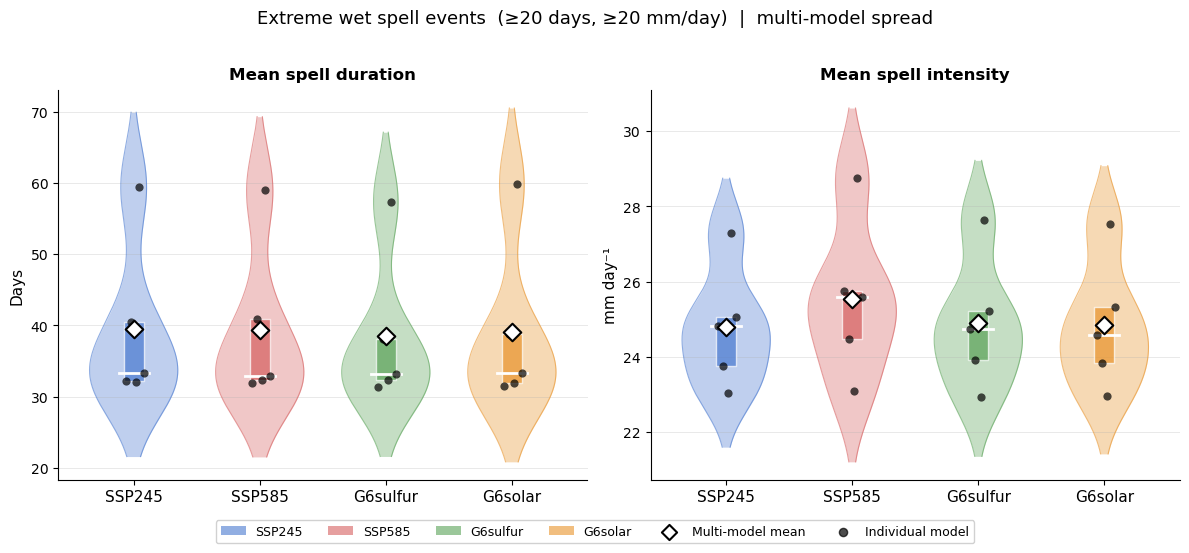

In [28]:
fig = plot_extreme_event_violin(
    df_20mm,
    title     = "Extreme wet spell events  (≥20 days, ≥20 mm/day)  |  multi-model spread",
    # save_path = "extreme_events_40mm_violin.png",
    # dpi       = 150,
)
display(fig)

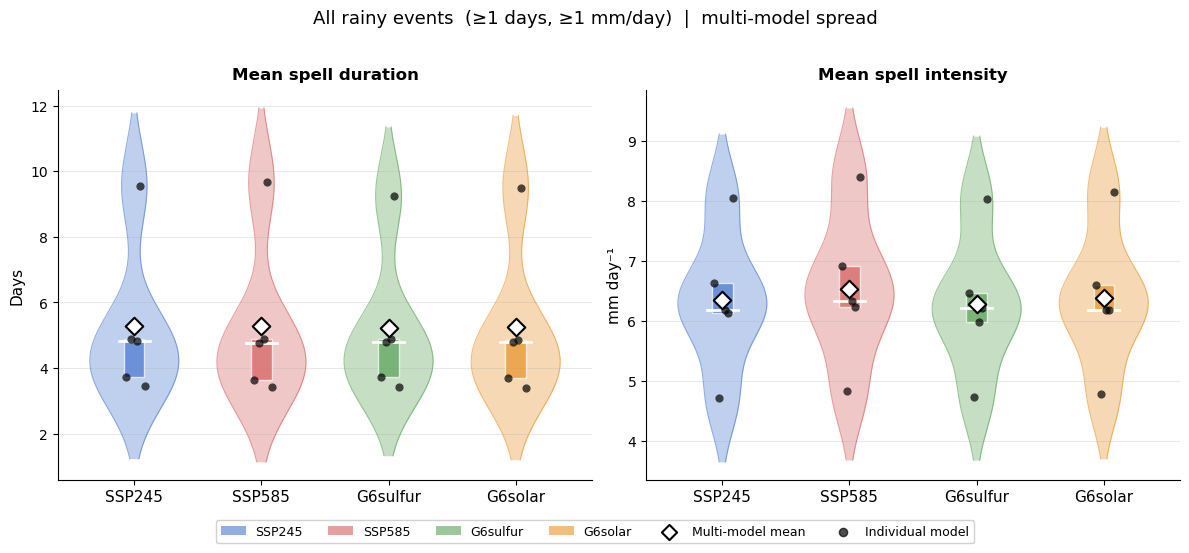

In [29]:
fig = plot_extreme_event_violin(
    df_extreme,
    title     = "All rainy events  (≥1 days, ≥1 mm/day)  |  multi-model spread",
    # save_path = "extreme_events_40mm_violin.png",
    # dpi       = 150,
)
display(fig)

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import gaussian_kde

# ================================================================
# PLOT 1: Total rainy days per experiment (multi-model mean + spread)
# ================================================================

def plot_total_rainy_days(df, title=None, save_path=None, dpi=150):
    """
    For each experiment, sum all event durations per model
    (= total rainy days in the tropics over the period).
    Show as violin + dots + mean diamond.
    """

    experiments = ["SSP245", "SSP585", "G6sulfur", "G6solar"]
    experiments = [e for e in experiments if e in df["experiment"].unique()]
    models      = sorted(df["model"].unique())

    colors = {
        "SSP245":   "#4878CF",
        "SSP585":   "#D65F5F",
        "G6sulfur": "#59A257",
        "G6solar":  "#E8932A",
    }

    # ── Per-model total rainy days ────────────────────────────────────────────
    model_total = {exp: [] for exp in experiments}

    for model in models:
        for exp in experiments:
            subset = df[(df["model"] == model) & (df["experiment"] == exp)]
            if subset.empty:
                continue
            # sum of all spell durations = total rainy days
            model_total[exp].append(subset["duration"].sum())

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))

    x_positions = np.arange(len(experiments))

    for i, exp in enumerate(experiments):
        vals = np.array(model_total[exp])
        if len(vals) == 0:
            continue
        col = colors[exp]
        x   = x_positions[i]

        # Violin
        if len(vals) >= 3:
            kde     = gaussian_kde(vals, bw_method=0.6)
            v_range = np.linspace(vals.min() - vals.std(),
                                  vals.max() + vals.std(), 200)
            density = kde(v_range)
            density = density / density.max() * 0.35
            ax.fill_betweenx(v_range, x - density, x + density,
                             color=col, alpha=0.35, linewidth=0)
            ax.plot(x - density, v_range, color=col, lw=0.8, alpha=0.6)
            ax.plot(x + density, v_range, color=col, lw=0.8, alpha=0.6)

        # IQR box
        q25, q75 = np.percentile(vals, [25, 75])
        ax.add_patch(mpatches.FancyBboxPatch(
            (x - 0.08, q25), 0.16, q75 - q25,
            boxstyle="square,pad=0",
            facecolor=col, edgecolor="white", alpha=0.7, zorder=3
        ))

        # Median line
        ax.plot([x - 0.12, x + 0.12], [np.median(vals)] * 2,
                color="white", lw=2, zorder=4)

        # Individual model dots
        jitter = (np.random.RandomState(42).rand(len(vals)) - 0.5) * 0.18
        ax.scatter(x + jitter, vals, color="k", s=40,
                   zorder=5, alpha=0.7, linewidths=0)

        # Multi-model mean diamond
        ax.scatter(x, vals.mean(), marker="D", s=90,
                   color="white", edgecolors="k",
                   linewidths=1.5, zorder=6)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(experiments, fontsize=12)
    ax.set_ylabel("Total rainy days (sum of spell durations)", fontsize=11)
    ax.grid(True, axis="y", lw=0.4, alpha=0.5)
    ax.set_xlim(-0.6, len(experiments) - 0.4)
    ax.spines[["top", "right"]].set_visible(False)

    legend_elements = [
        mpatches.Patch(facecolor=colors[exp], alpha=0.6, label=exp)
        for exp in experiments
    ] + [
        plt.scatter([], [], marker="D", s=60, color="white",
                    edgecolors="k", linewidths=1.5, label="Multi-model mean"),
        plt.scatter([], [], color="k", s=35, alpha=0.7,
                    label="Individual model"),
    ]
    ax.legend(handles=legend_elements, fontsize=9,
              framealpha=0.9, loc="best")

    if title is None:
        title = "Total rainy days in the tropics  |  multi-model spread"
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved → {save_path}")

    plt.close(fig)
    return fig


# ================================================================
# PLOT 2: Mean rainfall intensity vs spell length for each experiment
# ================================================================

def plot_intensity_vs_spell_length(df, max_duration=40,
                                    title=None, save_path=None, dpi=150):
    """
    For each spell length (1, 2, 3, ... max_duration days),
    compute the multi-model mean intensity of spells of that length.
    Plot as lines with shading for model spread (±1 std).
    One line per experiment.
    """

    experiments = ["SSP245", "SSP585", "G6sulfur", "G6solar"]
    experiments = [e for e in experiments if e in df["experiment"].unique()]
    models      = sorted(df["model"].unique())

    colors = {
        "SSP245":   "#4878CF",
        "SSP585":   "#D65F5F",
        "G6sulfur": "#59A257",
        "G6solar":  "#E8932A",
    }

    durations = np.arange(1, max_duration + 1)

    # ── Per-model mean intensity for each spell length ────────────────────────
    # shape: (n_models, n_durations) per experiment
    model_curves = {exp: [] for exp in experiments}

    for model in models:
        for exp in experiments:
            subset = df[(df["model"] == model) & (df["experiment"] == exp)]
            curve  = []
            for d in durations:
                spells = subset[subset["duration"] == d]["mean_intensity"]
                if len(spells) == 0:
                    curve.append(np.nan)
                else:
                    curve.append(spells.mean())
            model_curves[exp].append(curve)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 5))

    for exp in experiments:
        arr = np.array(model_curves[exp])   # (n_models, n_durations)

        # multi-model mean and std — ignore duration bins with no data
        mm_mean = np.nanmean(arr, axis=0)
        mm_std  = np.nanstd(arr,  axis=0)

        # mask durations where fewer than 2 models have data
        n_valid = np.sum(np.isfinite(arr), axis=0)
        mm_mean[n_valid < 2] = np.nan
        mm_std[n_valid  < 2] = np.nan

        col = colors[exp]

        # Shaded spread
        ax.fill_between(durations,
                        mm_mean - mm_std,
                        mm_mean + mm_std,
                        color=col, alpha=0.15, linewidth=0)

        # Mean line
        ax.plot(durations, mm_mean,
                color=col, lw=2, label=exp)

        # Individual model lines (thin, transparent)
        for curve in arr:
            ax.plot(durations, curve,
                    color=col, lw=0.6, alpha=0.3)

    ax.set_xlabel("Spell length (days)", fontsize=12)
    ax.set_ylabel("Mean rainfall intensity (mm day⁻¹)", fontsize=11)
    ax.set_xlim(1, max_duration)
    ax.set_xticks(np.arange(0, max_duration + 1, 5))
    ax.grid(True, lw=0.4, alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=10, framealpha=0.9)

    if title is None:
        title = "Mean rainfall intensity vs spell length  |  multi-model mean ± std"
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved → {save_path}")

    plt.close(fig)
    return fig


def plot_total_rainy_days_anomaly(df, baseline_exp="SSP245",
                                   title=None, save_path=None, dpi=150):
    """
    For each experiment, compute the difference in total rainy days
    relative to baseline_exp, per model, then show multi-model spread.
    """

    experiments = ["SSP245", "SSP585", "G6sulfur", "G6solar"]
    experiments = [e for e in experiments if e in df["experiment"].unique()]
    other_exps  = [e for e in experiments if e != baseline_exp]
    models      = sorted(df["model"].unique())

    colors = {
        "SSP245":   "#4878CF",
        "SSP585":   "#D65F5F",
        "G6sulfur": "#59A257",
        "G6solar":  "#E8932A",
    }

    # ── Per-model total rainy days for every experiment ───────────────────────
    model_total = {exp: {} for exp in experiments}

    for model in models:
        for exp in experiments:
            subset = df[(df["model"] == model) & (df["experiment"] == exp)]
            model_total[exp][model] = subset["duration"].sum() if not subset.empty else np.nan

    # ── Anomaly per model: exp - baseline ─────────────────────────────────────
    model_delta = {exp: [] for exp in other_exps}

    for model in models:
        base_val = model_total[baseline_exp].get(model, np.nan)
        for exp in other_exps:
            exp_val = model_total[exp].get(model, np.nan)
            model_delta[exp].append(exp_val - base_val)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))

    # Zero reference
    ax.axhline(0, color="k", lw=1.2, linestyle="--", alpha=0.5,
               label=f"{baseline_exp} (baseline)")

    x_positions = np.arange(len(other_exps))

    for i, exp in enumerate(other_exps):
        vals = np.array(model_delta[exp])
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue

        col = colors[exp]
        x   = x_positions[i]

        # Violin
        if len(vals) >= 3:
            kde     = gaussian_kde(vals, bw_method=0.6)
            v_range = np.linspace(vals.min() - vals.std(),
                                  vals.max() + vals.std(), 200)
            density = kde(v_range)
            density = density / density.max() * 0.35
            ax.fill_betweenx(v_range, x - density, x + density,
                             color=col, alpha=0.35, linewidth=0)
            ax.plot(x - density, v_range, color=col, lw=0.8, alpha=0.6)
            ax.plot(x + density, v_range, color=col, lw=0.8, alpha=0.6)

        # IQR box
        q25, q75 = np.percentile(vals, [25, 75])
        ax.add_patch(mpatches.FancyBboxPatch(
            (x - 0.08, q25), 0.16, q75 - q25,
            boxstyle="square,pad=0",
            facecolor=col, edgecolor="white", alpha=0.7, zorder=3
        ))

        # Median line
        ax.plot([x - 0.12, x + 0.12], [np.median(vals)] * 2,
                color="white", lw=2, zorder=4)

        # Individual model dots
        jitter = (np.random.RandomState(42).rand(len(vals)) - 0.5) * 0.18
        ax.scatter(x + jitter, vals, color="k", s=40,
                   zorder=5, alpha=0.7, linewidths=0)

        # Multi-model mean diamond
        ax.scatter(x, np.nanmean(vals), marker="D", s=90,
                   color="white", edgecolors="k",
                   linewidths=1.5, zorder=6)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(other_exps, fontsize=12)
    ax.set_ylabel(f"Δ total rainy days relative to {baseline_exp}", fontsize=11)
    ax.grid(True, axis="y", lw=0.4, alpha=0.5)
    ax.set_xlim(-0.6, len(other_exps) - 0.4)
    ax.spines[["top", "right"]].set_visible(False)

    legend_elements = [
        mpatches.Patch(facecolor=colors[exp], alpha=0.6, label=exp)
        for exp in other_exps
    ] + [
        plt.scatter([], [], marker="D", s=60, color="white",
                    edgecolors="k", linewidths=1.5, label="Multi-model mean"),
        plt.scatter([], [], color="k", s=35, alpha=0.7,
                    label="Individual model"),
    ]
    ax.legend(handles=legend_elements, fontsize=9,
              framealpha=0.9, loc="best")

    if title is None:
        title = (f"Δ total rainy days relative to {baseline_exp}"
                 f"  |  multi-model spread")
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved → {save_path}")

    plt.close(fig)
    return fig


def plot_intensity_vs_spell_length_anomaly(df, baseline_exp="SSP245",
                                            max_duration=40,
                                            title=None, save_path=None, dpi=150):
    """
    For each spell length (1 .. max_duration days), compute the
    multi-model mean intensity anomaly relative to baseline_exp.
    Shading = ±1 std across models.
    """

    experiments = ["SSP245", "SSP585", "G6sulfur", "G6solar"]
    experiments = [e for e in experiments if e in df["experiment"].unique()]
    other_exps  = [e for e in experiments if e != baseline_exp]
    models      = sorted(df["model"].unique())

    colors = {
        "SSP245":   "#4878CF",
        "SSP585":   "#D65F5F",
        "G6sulfur": "#59A257",
        "G6solar":  "#E8932A",
    }

    durations = np.arange(1, max_duration + 1)

    # ── Per-model intensity curve for every experiment ────────────────────────
    model_curves = {exp: [] for exp in experiments}

    for model in models:
        for exp in experiments:
            subset = df[(df["model"] == model) & (df["experiment"] == exp)]
            curve  = []
            for d in durations:
                spells = subset[subset["duration"] == d]["mean_intensity"]
                curve.append(spells.mean() if len(spells) > 0 else np.nan)
            model_curves[exp].append(curve)

    model_curves = {exp: np.array(model_curves[exp]) for exp in experiments}
    # shape: (n_models, n_durations)

    # ── Anomaly = exp - baseline, computed per model before averaging ─────────
    baseline_arr = model_curves[baseline_exp]   # (n_models, n_durations)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 5))

    # Zero reference line
    ax.axhline(0, color="k", lw=1.2, linestyle="--", alpha=0.5,
               label=f"{baseline_exp} (baseline)")

    for exp in other_exps:
        arr   = model_curves[exp]                    # (n_models, n_durations)
        delta = arr - baseline_arr                   # per-model anomaly

        mm_mean = np.nanmean(delta, axis=0)
        mm_std  = np.nanstd(delta,  axis=0)

        # Mask durations where fewer than 2 models have data in either exp
        n_valid = np.sum(np.isfinite(delta), axis=0)
        mm_mean[n_valid < 2] = np.nan
        mm_std[n_valid  < 2] = np.nan

        col = colors[exp]

        # Shaded ±1 std
        ax.fill_between(durations,
                        mm_mean - mm_std,
                        mm_mean + mm_std,
                        color=col, alpha=0.15, linewidth=0)

        # Multi-model mean line
        ax.plot(durations, mm_mean, color=col, lw=2.5, label=exp)

        # Individual model anomaly lines
        for d in delta:
            ax.plot(durations, d, color=col, lw=0.5, alpha=0.25)

    ax.set_xlabel("Spell length (days)", fontsize=12)
    ax.set_ylabel(f"Δ mean intensity relative to {baseline_exp}\n(mm day⁻¹)",
                  fontsize=11)
    ax.set_xlim(1, max_duration)
    ax.set_xticks(np.arange(0, max_duration + 1, 5))
    ax.grid(True, lw=0.4, alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=10, framealpha=0.9)

    if title is None:
        title = (f"Mean rainfall intensity anomaly vs spell length  "
                 f"|  relative to {baseline_exp}  |  multi-model mean ± std")
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved → {save_path}")

    plt.close(fig)
    return fig

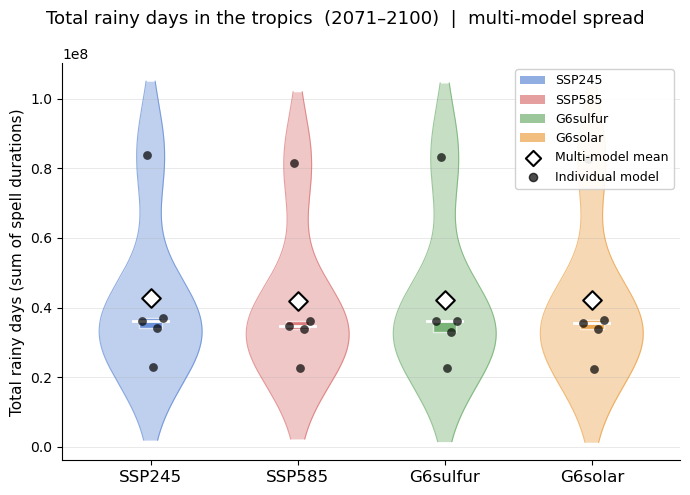

In [31]:

# ================================================================
# CALLS
# ================================================================
from IPython.display import display

fig1 = plot_total_rainy_days(
    df_extreme,
    title = "Total rainy days in the tropics  (2071–2100)  |  multi-model spread",
)
display(fig1)

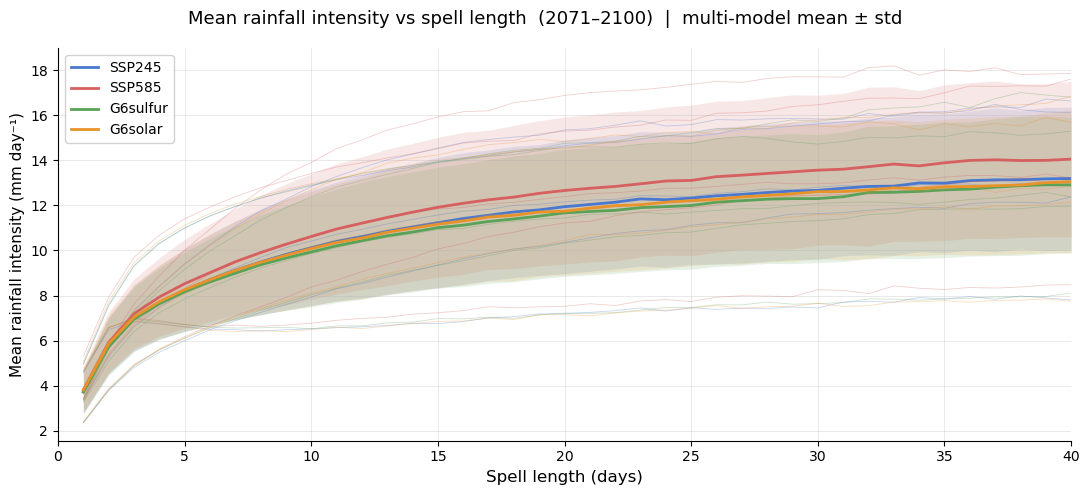

In [32]:
fig2 = plot_intensity_vs_spell_length(
    df_extreme,
    max_duration = 40,
    title = "Mean rainfall intensity vs spell length  (2071–2100)  |  multi-model mean ± std",
)
display(fig2)

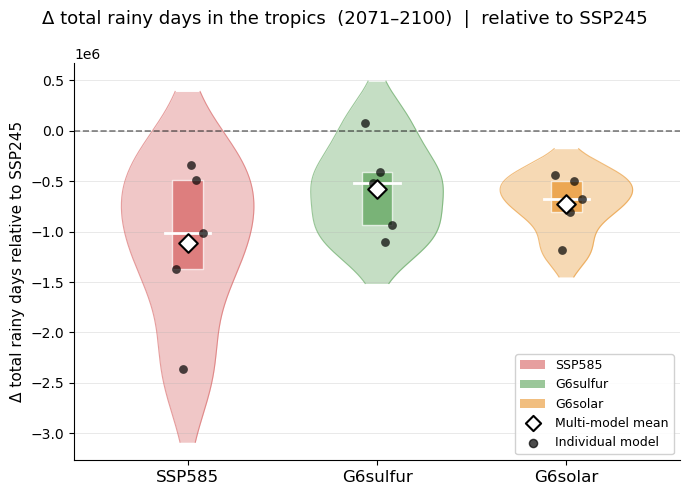

In [35]:
# ── Call ──────────────────────────────────────────────────────────────────────
fig = plot_total_rainy_days_anomaly(
    df_extreme,
    baseline_exp = "SSP245",
    title        = "Δ total rainy days in the tropics  (2071–2100)  |  relative to SSP245",
)
display(fig)

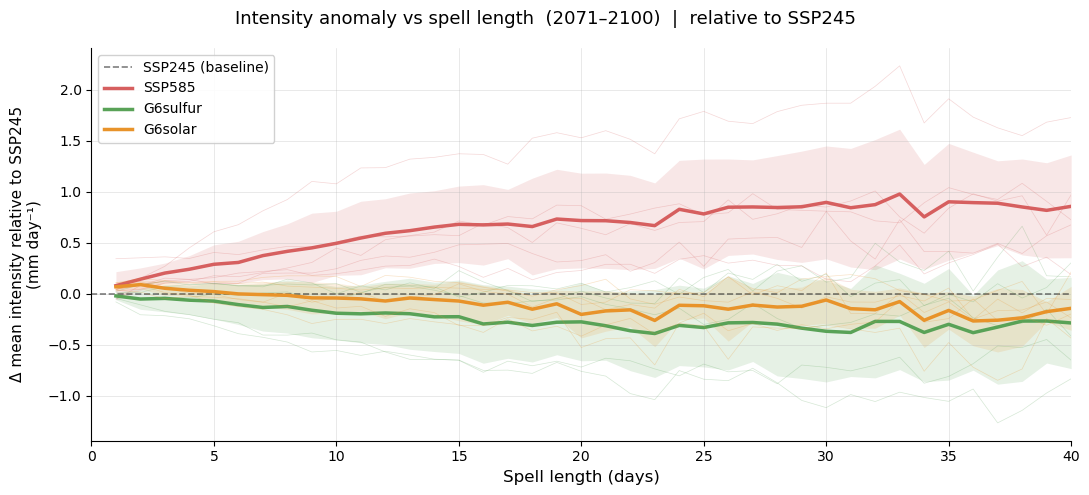

In [33]:
# ── Call ──────────────────────────────────────────────────────────────────────
fig = plot_intensity_vs_spell_length_anomaly(
    df_extreme,
    baseline_exp = "SSP245",
    max_duration = 40,
    title        = "Intensity anomaly vs spell length  (2071–2100)  |  relative to SSP245",
)
display(fig)